# **Project Name**    -  IndiGo Airline Passenger Referral Prediction



##### **Project Type**    -  Classification
##### **Contributor -**   Aryan Roy


# **Project Summary -**

The airline industry plays a crucial role in modern transportation, with numerous airlines serving various routes worldwide. To make informed decisions in this highly competitive industry, airlines and stakeholders rely on data-driven insights. Machine learning models are indispensable tools in this regard, allowing for the classification of airlines based on different criteria. This document outlines the development and implementation of an airline classification machine learning model.


This is where machine learning can play a vital role. By using historical customer data, a machine learning model can identify patterns and correlations that indicate a high likelihood of referral. This information can then be used by airlines to target specific customers with personalized marketing campaigns or incentives, increasing the chances of referral and promoting growth.


In conclusion, a machine learning model that predicts the likelihood of referral can provide valuable insights for airlines looking to enhance their customer satisfaction and drive growth through word-of-mouth referrals.



# **Problem Statement**


The goal of this machine learning project is to classify airlines into categories based on certain features or attributes. Classification can serve multiple purposes, such as identifying potential partners for codeshare agreements, assisting in pricing strategies, or aiding in market analysis. In this project, We will be exploring if flyers would recommend the airline to their friends and families, based on their travel experience,reviews and ratings.

#### There are few problems that we are looking in this project:

* Develop a classification model to categorize airlines based on the likelihood of customers recommending them to friends and family.

* Recognize the pivotal role of customer satisfaction and referrals in the growth and success of airlines.

* Enable airlines to strategically utilize customer referral information for codeshare agreements, pricing strategies, and market analysis.

* Identify customers likely to refer the airline, a task complicated by the diverse factors influencing satisfaction and referrals.

* Assess the model's capability to provide actionable insights for airlines to tailor services, improve customer satisfaction, and enhance brand reputation.


This problem statement outlines the key objectives, challenges, and considerations for developing a classification model to predict customer referrals in the airline industry.

## ***1. Know Your Data***

### Import Libraries

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00


In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import datetime as dt
import missingno as msno
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV , cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

### Dataset Loading

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import pandas as pd
df1 = pd.read_csv('/content/drive/MyDrive/data_airline_reviews.xlsx.csv')

### Dataset First View

In [18]:
# Dataset First Look
df1.head()

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,NaN,Business,Economy Class,London to Izmir via Istanbul,May-19,4.0,5.0,4.0,4.0,2.0,4.0,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,NaN,Family Leisure,Economy Class,Istanbul to Bucharest,May-19,4.0,1.0,1.0,1.0,1.0,1.0,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dataset Rows & Columns count

In [19]:
# Dataset Rows & Columns count
df1.shape

(131895, 17)

### Dataset Information

In [20]:
# Dataset Info
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131895 entries, 0 to 131894
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          65947 non-null  object 
 1   overall          64017 non-null  float64
 2   author           65947 non-null  object 
 3   review_date      65947 non-null  object 
 4   customer_review  65947 non-null  object 
 5   aircraft         19718 non-null  object 
 6   traveller_type   39755 non-null  object 
 7   cabin            63303 non-null  object 
 8   route            39726 non-null  object 
 9   date_flown       39633 non-null  object 
 10  seat_comfort     60681 non-null  float64
 11  cabin_service    60715 non-null  float64
 12  food_bev         52608 non-null  float64
 13  entertainment    44193 non-null  float64
 14  ground_service   39358 non-null  float64
 15  value_for_money  63975 non-null  float64
 16  recommended      64440 non-null  object 
dtypes: float64

#### Duplicate Values

In [21]:
# Dataset Duplicate Value Count
df1.duplicated().sum()

np.int64(70711)

#### Missing Values/Null Values

In [22]:
# Missing Values/Null Values Count
df1.isnull().sum()

,0
airline,65948
overall,67878
author,65948
review_date,65948
customer_review,65948
aircraft,112177
traveller_type,92140
cabin,68592
route,92169
date_flown,92262


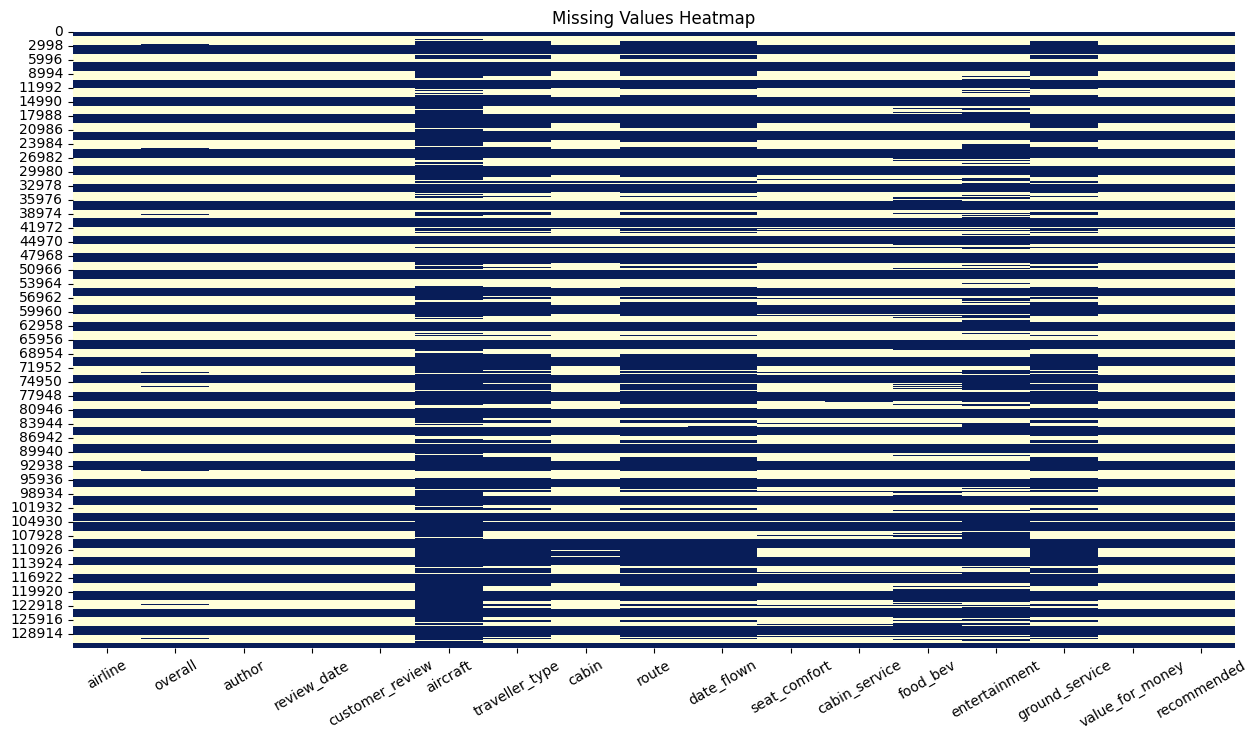

In [23]:
#Visualizing Missing Values
plt.figure(figsize=(15,8))
sns.heatmap(df1.isnull(), cbar=False, cmap='YlGnBu')
plt.title('Missing Values Heatmap')
plt.xticks(rotation=30)
plt.show()

### What did you know about your dataset?

Data includes airline reviews from 2006 to 2019 for popular airlines around the world with user feedback ratings and reviews based on their travel experience.

It has 131895 rows 17 different columns.

Data is scraped in Spring 2019. Feature descriptions briefly as follows:

1. **airline** - Airline name
2. **overall** - Overall score
3. **Author** - Author information
4. **review_date** - Customer Review posted date
5. **Customer_review** - Actual customer review(Textual)
6. **aircraft** - Type of aircraft
7. **traveller_type** - Type of traveller
8. **cabin**- Cabin type chosen by traveller (Economy, Business,Premium economy,First class)
9. **route** - Route flown by flyer
10. **date_flown** - Date of travel
11. **seat_comfort** - Rating provided towards seat comfort
12. **cabin_service** - Rating provided towards cabin service.
13. **food_bev** - Rating provided towards food and beverages supplied during travel.
14. **entertainment** - Rating provided towards on board flight entertainment
15. **ground_service** - Rating provided towards ground service staff.
16. **value_for_money** - Rating provided towards value for money.
17. **recommended** - Airline service Recommended by flyer (Yes/No)

## ***2. Understanding Your Variables***

In [24]:
# Dataset Columns
df1.columns

Index(['airline', 'overall', 'author', 'review_date', 'customer_review',
       'aircraft', 'traveller_type', 'cabin', 'route', 'date_flown',
       'seat_comfort', 'cabin_service', 'food_bev', 'entertainment',
       'ground_service', 'value_for_money', 'recommended'],
      dtype='object')

In [25]:
# Dataset Describe
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
overall,64017.0,5.145430,3.477532,1.0,1.0,5.0,9.0,10.0
seat_comfort,60681.0,2.952160,1.441362,1.0,1.0,3.0,4.0,5.0
cabin_service,60715.0,3.191814,1.565789,1.0,2.0,3.0,5.0,5.0
food_bev,52608.0,2.908170,1.481893,1.0,1.0,3.0,4.0,5.0
entertainment,44193.0,2.863372,1.507262,1.0,1.0,3.0,4.0,5.0
ground_service,39358.0,2.692820,1.612215,1.0,1.0,3.0,4.0,5.0
value_for_money,63975.0,2.943962,1.587370,1.0,1.0,3.0,4.0,5.0


### Variables Description

It has lot of blank rows with many null values and the columns description are as follows:

1. **airline** - Name of the airline.  (**object type**)
2. **overall** - Overall rating defined by customer. (**float type**)
3. **Author** - Customer information. (**object type**)
4. **review_date** - date on which customer posted a review. (**object type**)
5. **Customer_review** - Description of customer review. (**object type**)
6. **aircraft** - Type of aircraft. (**object type**)
7. **traveller_type** - Type of traveller. (**object type**)
8. **cabin**- Cabin type chosen by traveller. (Economy, Business,Premium economy,First class) (**object type**)
9. **route** - Route flown by flyer. (**object type**)
10. **date_flown** - Date of travel. (**object type**)
11. **seat_comfort** - Rating provided towards seat comfort. (**float type**)
12. **cabin_service** - Rating provided towards cabin service. (**float type**)
13. **food_bev** - Rating provided towards food and beverages supplied during travel. (**float type**)
14. **entertainment** - Rating provided towards on board flight entertainment. (**float type**)
15. **ground_service** - Rating provided towards ground service staff. (**float type**)
16. **value_for_money** - Rating provided towards value for money. (**float type**)
17. **recommended** - Airline service Recommended by flyer (Yes/No). (**object type**)

### Check Unique Values for each variable.

In [26]:
#Check for unique values exclude the NaN values
for i in df1.columns.tolist():
  print("No. of unique values in ",i,"is",df1[i].nunique())

No. of unique values in  airline is 81
No. of unique values in  overall is 10
No. of unique values in  author is 44069
No. of unique values in  review_date is 3015
No. of unique values in  customer_review is 61172
No. of unique values in  aircraft is 2088
No. of unique values in  traveller_type is 4
No. of unique values in  cabin is 4
No. of unique values in  route is 24549
No. of unique values in  date_flown is 63
No. of unique values in  seat_comfort is 5
No. of unique values in  cabin_service is 5
No. of unique values in  food_bev is 5
No. of unique values in  entertainment is 5
No. of unique values in  ground_service is 5
No. of unique values in  value_for_money is 5
No. of unique values in  recommended is 2


## 3. ***Data Wrangling***

### Data Wrangling Code

* First we made a copy of our data for safety purpose.

In [27]:
# Make a copy of your dataset for in future revert back
df=df1.copy()

* As there are many NaN values rows so we have drop all duplicated rows.

In [28]:
#Drop all duplicated rows as there are many blank and duplicated rows
df.drop_duplicates(inplace=True)

* After dropping all duplicated rows we are reseting our index.

In [29]:
#Drop the index column
df.reset_index(drop=True, inplace=True)

* Now we checked the shape of data after dropping.

In [30]:
#Check for shape of your dataset
df.shape

(61184, 17)

* Now check for sum of NaN values and sort it according to the sum.

In [31]:
#check for null values and sort in ascending order
df.isnull().sum().sort_values(ascending=False)

,0
aircraft,42696
ground_service,24015
date_flown,23750
route,23671
traveller_type,23644
entertainment,20954
food_bev,12843
seat_comfort,4973
cabin_service,4944
cabin,2479


* Now we are dropping our unwanted columns like `author`, `customer_review`, `route`.

In [32]:
#Drop unwanted columns that is not used for our analysis
df.drop(columns=(['author','customer_review','route']),axis=1,inplace=True)

* Here we are dropping our `aircraft` column because it almost have `70% NaN values`.

In [33]:
#In this we have too many null values so we dropped it and it can't be filled also
df.drop(columns=['aircraft'],axis=1,inplace=True)

* Now we are again checking how much NaN values left.

In [34]:
# Again check for null values and sort in ascending order
df.isnull().sum().sort_values(ascending=False)

,0
ground_service,24015
date_flown,23750
traveller_type,23644
entertainment,20954
food_bev,12843
seat_comfort,4973
cabin_service,4944
cabin,2479
value_for_money,1857
overall,1783


* Here we are droping nan values rows for these two columns named `ground_service` and `entertainment`.

In [35]:
#Drop null values for these 2 columns
df.dropna(subset=(['ground_service','entertainment']),inplace=True)

* We are again checking for NaN values.

In [36]:
# Again check for null values and sort in ascending order
df.isnull().sum().sort_values(ascending=False)

,0
food_bev,782
cabin,13
date_flown,10
traveller_type,2
overall,1
seat_comfort,1
cabin_service,1
review_date,0
airline,0
entertainment,0


* Here we are imputing our NaN values of `food_bev` with the mean.

In [37]:
#Fill the null vales with mean fo their rating
df['food_bev'].fillna(df['food_bev'].mean(),inplace=True)

/tmp/ipython-input-37-4102718950.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['food_bev'].fillna(df['food_bev'].mean(),inplace=True)


* Now again here we are dropping rest all NaN values.

In [38]:
#Drop all null values in our whole dataset
df.dropna(inplace=True)

* Now we are finally checking null values after handling all our missing/NaN values.

In [39]:
#Final check for null values
df.isnull().sum()

,0
airline,0
overall,0
review_date,0
traveller_type,0
cabin,0
date_flown,0
seat_comfort,0
cabin_service,0
food_bev,0
entertainment,0


* We can check our number of rows and columns after removing all NaN values.

In [40]:
# Check for shape after cleaning or dataset
df.shape

(23606, 13)

* Resetting our index after cleaning.

In [41]:
#First row is all null values so after we dropped it our index starts from 1 so we are resetting or index
df.reset_index(drop=True, inplace=True)

* Check first five rows of the data after cleaning.

In [42]:
#Check first 5 rows of dataset after cleaning
df.head()

,airline,overall,review_date,traveller_type,cabin,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,Turkish Airlines,7.0,8th May 2019,Business,Economy Class,May-19,4.0,5.0,4.0,4.0,2.0,4.0,yes
1,Turkish Airlines,2.0,7th May 2019,Family Leisure,Economy Class,May-19,4.0,1.0,1.0,1.0,1.0,1.0,no
2,Turkish Airlines,3.0,7th May 2019,Business,Economy Class,May-19,1.0,4.0,1.0,3.0,1.0,2.0,no
3,Turkish Airlines,10.0,6th May 2019,Solo Leisure,Economy Class,April 2019,4.0,5.0,5.0,5.0,5.0,5.0,yes
4,Turkish Airlines,1.0,6th May 2019,Solo Leisure,Economy Class,May-19,1.0,1.0,1.0,1.0,1.0,1.0,no


### Outliers Detection and Removal

<Axes: >

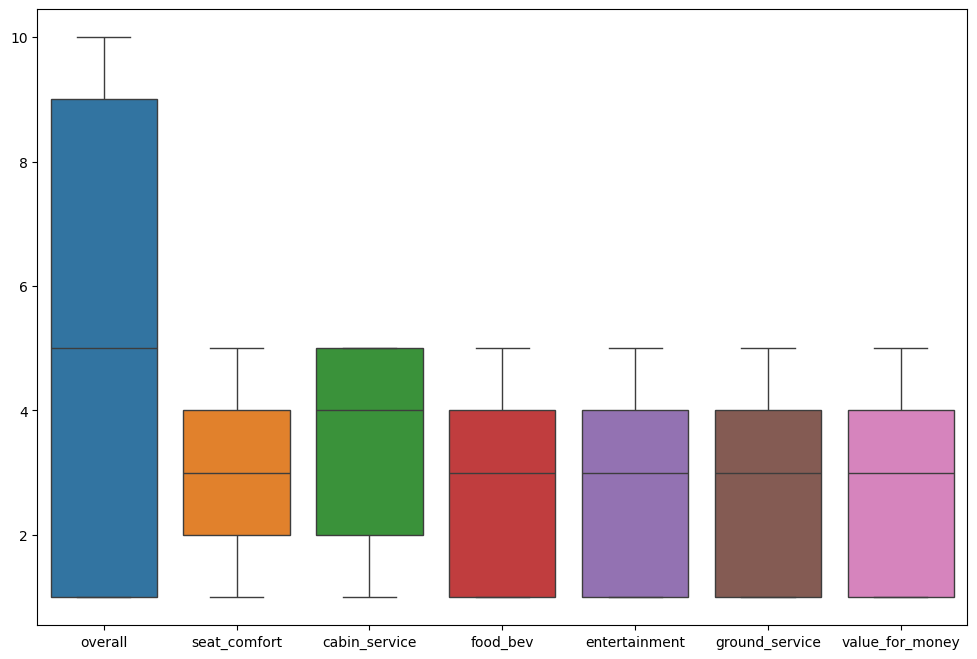

In [43]:
#Plot the boxplot for all columns to check for outliers
plt.figure(figsize=(12,8))
sns.boxplot(df)

## Data manipulation

* Check for info about our data.

In [44]:
#Check for Datatypes of columns in our dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23606 entries, 0 to 23605
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          23606 non-null  object 
 1   overall          23606 non-null  float64
 2   review_date      23606 non-null  object 
 3   traveller_type   23606 non-null  object 
 4   cabin            23606 non-null  object 
 5   date_flown       23606 non-null  object 
 6   seat_comfort     23606 non-null  float64
 7   cabin_service    23606 non-null  float64
 8   food_bev         23606 non-null  float64
 9   entertainment    23606 non-null  float64
 10  ground_service   23606 non-null  float64
 11  value_for_money  23606 non-null  float64
 12  recommended      23606 non-null  object 
dtypes: float64(7), object(6)
memory usage: 2.3+ MB


1. we can see there are many variables having not appropriate datatypes so we changed them to their suitable datatypes below.

In [45]:
d_type={'overall':'int8','review_date':'datetime64[ns]','seat_comfort':'int8','cabin_service':'int8','food_bev':'int8','entertainment':'int8',
        'ground_service':'int8',
        'value_for_money':'int8'}
for i,j in d_type.items():
  df[i]=df[i].astype(j)

* Cross check that datatype is changed or not.

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23606 entries, 0 to 23605
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   airline          23606 non-null  object        
 1   overall          23606 non-null  int8          
 2   review_date      23606 non-null  datetime64[ns]
 3   traveller_type   23606 non-null  object        
 4   cabin            23606 non-null  object        
 5   date_flown       23606 non-null  object        
 6   seat_comfort     23606 non-null  int8          
 7   cabin_service    23606 non-null  int8          
 8   food_bev         23606 non-null  int8          
 9   entertainment    23606 non-null  int8          
 10  ground_service   23606 non-null  int8          
 11  value_for_money  23606 non-null  int8          
 12  recommended      23606 non-null  object        
dtypes: datetime64[ns](1), int8(7), object(5)
memory usage: 1.2+ MB


Here we can see all columns are in their suitable datatype

2. Here converted `date_flown` column in a proper date format by removing timestamp and changed to Datetime format.

In [47]:
df['date_flown']=pd.to_datetime(df['date_flown'], errors='coerce')

/tmp/ipython-input-47-1841259172.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_flown']=pd.to_datetime(df['date_flown'], errors='coerce')


3. Renamed `overall` to `overall_rating` and `date_flown` to `departure_date` for better understanding.

In [48]:
rename_col={'overall':'overall_rating','date_flown':'departure_date'}
df.rename(columns=rename_col,inplace=True)

In [49]:
df.head()

,airline,overall_rating,review_date,traveller_type,cabin,departure_date,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,Turkish Airlines,7,2019-05-08,Business,Economy Class,NaT,4,5,4,4,2,4,yes
1,Turkish Airlines,2,2019-05-07,Family Leisure,Economy Class,NaT,4,1,1,1,1,1,no
2,Turkish Airlines,3,2019-05-07,Business,Economy Class,NaT,1,4,1,3,1,2,no
3,Turkish Airlines,10,2019-05-06,Solo Leisure,Economy Class,2019-04-01,4,5,5,5,5,5,yes
4,Turkish Airlines,1,2019-05-06,Solo Leisure,Economy Class,NaT,1,1,1,1,1,1,no


### What all manipulations have you done and insights you found?

1. Converted Date columns to datetime format as they were in object datatype and converted various rating columns from float to int as all ratings are only in integers.
2. date_flown column was not in proper date format it also contained Timestamp so we changed to a proper date format by removing timestamp and converted it into datetime datatype.
3. Renamed overall to overall_rating and date_flown to departure_date for better understanding.

# ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1: `Bar Chart` for comparing top 10 airlines based on highest trips

/tmp/ipython-input-51-999358126.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=air_cnt['count'], x=air_cnt['airline'], palette=palette)


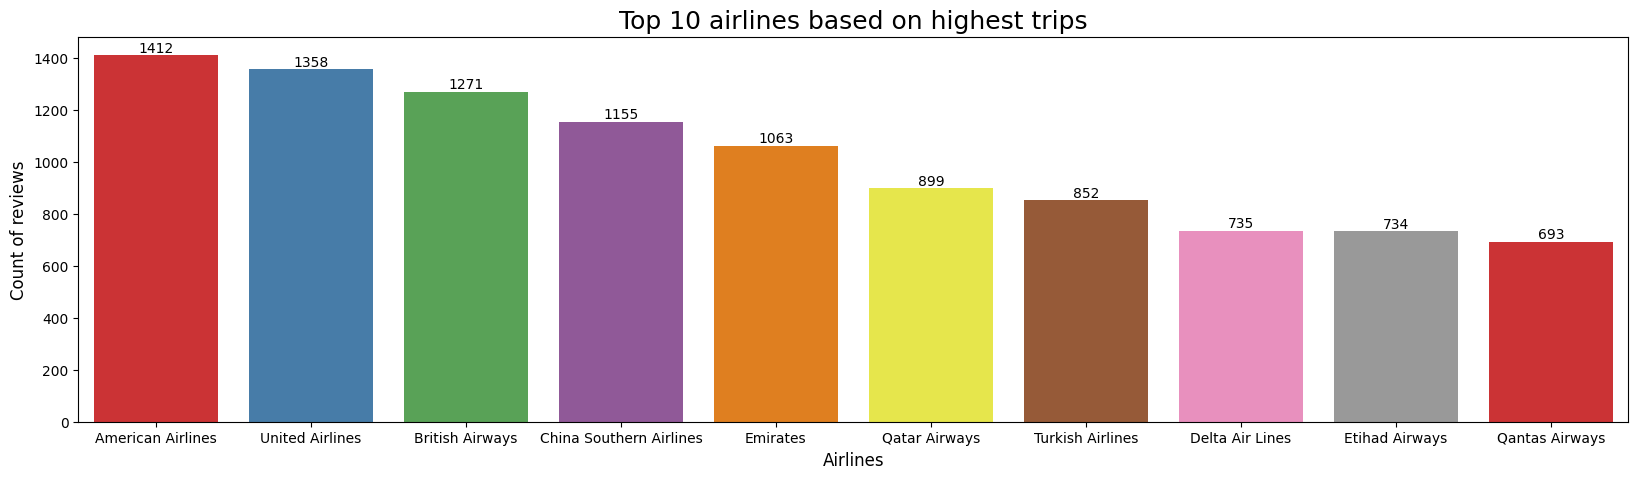

In [51]:
# Chart - 1 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,5))

# Get top 10 airlines by review count
air_cnt = df['airline'].value_counts().sort_values(ascending=False).head(10).reset_index()
air_cnt.columns = ['airline', 'count']  # Rename columns for clarity

# Plotting
palette = sns.color_palette("Set1", 10)
ax = sns.barplot(y=air_cnt['count'], x=air_cnt['airline'], palette=palette)

plt.xlabel('Airlines', fontsize=12)
plt.ylabel('Count of reviews', fontsize=12)
plt.title('Top 10 airlines based on highest trips', fontsize=18)

# Add labels
for num in ax.containers:
    ax.bar_label(num)

plt.show()

##### 1. Why did you pick the specific chart?

`Bar graph` is typically used when we have to depict categorical values with numerical values and here it suits well as we are to show airlines with its count of reviews

##### 2. What is/are the insight(s) found from the chart?

We have shown `top 10 airlines` in terms of their reviews count and can understand that `American Airlines` has the most number of review i.e.1412 reviews followed by `United Airlines` having 1358 reviews and `Bristish Airways` having 1271 reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It's essential to consider the nature of the reviews, the sentiments expressed, Understanding what customers appreciate about an airline, whether it's excellent service, punctuality, or other positive aspects, can help the company leverage and enhance these strengths and Identifying common issues or complaints allows the airline to address and rectify problems, leading to an improved customer experience.



#### Chart - 2 : ` Pie chart` for showing distribution of diffrent cabin classes preffered by passengers



In [52]:
cab_cnt=df['cabin'].value_counts().reset_index()

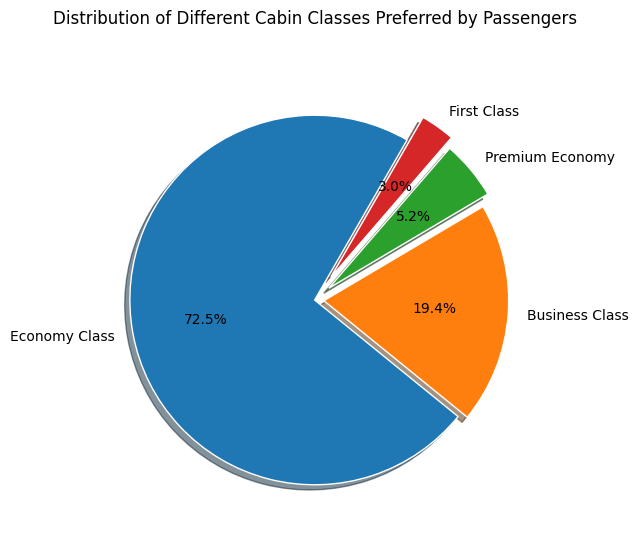

In [58]:
# Chart - 2 visualization code
import matplotlib.pyplot as plt

# Step 1: Count the cabin values and reset index
cab_cnt = df['cabin'].value_counts().reset_index()

# Step 2: Rename the columns to avoid confusion
cab_cnt.columns = ['cabin', 'count']

# Step 3: Make sure the explode list matches the number of unique cabin classes
explode = [0.05 * i for i in range(len(cab_cnt))]  # Dynamic explode based on length

# Step 4: Plot the pie chart
plt.figure(figsize=(12,6))
plt.pie(
    cab_cnt['count'],
    labels=cab_cnt['cabin'],
    autopct='%1.1f%%',
    explode=explode,
    startangle=60,
    textprops={'fontsize': 10},
    shadow=True,
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Distribution of Different Cabin Classes Preferred by Passengers', y=1.08, fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A `pie chart` is a circular statistical graphic that is divided into slices to illustrate numerical proportions. It's primarily used to show the relationship of parts to a whole.

##### 2. What is/are the insight(s) found from the chart?

From the above chart we can see that `econony class`(72.5%) constitues the largest part followed by `business class`(19.4%)and the other two class `Premium`(5.2%) and `First Class`(3.0%) constitues very less portion of the chart which tells that mostly people were travelling in economy class .

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the popularity of economy class can guide the airline in customizing services to meet the needs and expectations of this larger customer segment,Given that economy class is the most popular, marketing efforts can be targeted towards this segment. Promotions, loyalty programs, and advertising can be tailored to attract and retain economy class travelers.

#### Chart - 3: `Bar Chart` for comparing most popular cabin type

/tmp/ipython-input-57-2090203780.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=most_trav['traveller_type'], y=most_trav['count'], palette='Dark2')


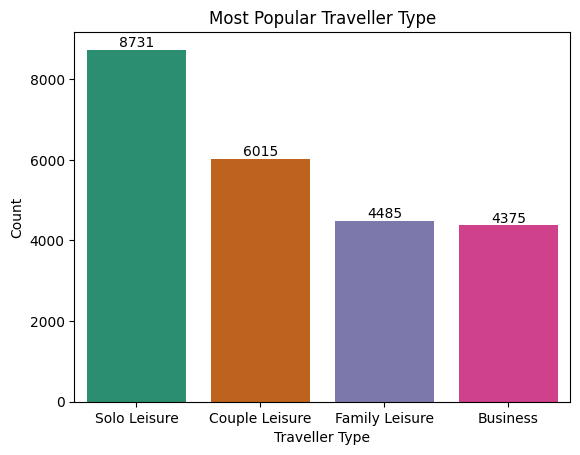

In [57]:
# Chart - 3 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# Get counts and rename columns
most_trav = df["traveller_type"].value_counts().reset_index()
most_trav.columns = ['traveller_type', 'count']

# Plot
ax = sns.barplot(x=most_trav['traveller_type'], y=most_trav['count'], palette='Dark2')
plt.ylabel('Count')
plt.xlabel('Traveller Type')
plt.title('Most Popular Traveller Type')

for num in ax.containers:
    ax.bar_label(num)

plt.show()

##### 1. Why did you pick the specific chart?

`Bar graph` is typically used when we have to depict categorical values with numerical values and here it suits well as we are to show air

##### 2. What is/are the insight(s) found from the chart?

`Solo Leisure` is the most preffered travel_type by passengers while `Bussiness` is the lowest travel_type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding that solo leisure travel is more popular allows the airline to tailor marketing efforts specifically toward this segment. Promotions, advertising, and loyalty programs can be designed to attract and retain solo leisure travelers, potentially increasing customer acquisition and retention.

#### Chart - 4: `Side by side Bar Chart` for comparing cabin classes based on food_bev and entertainment ratings

*  Average ratings of Food_bev and entertainment given by passenger in various cabin

In [59]:
#performing the grouphby method
eda_4=df.groupby('cabin')[['food_bev','entertainment']].mean().reset_index()
eda_4

,cabin,food_bev,entertainment
0,Business Class,3.509517,3.406913
1,Economy Class,2.625146,2.688859
2,First Class,3.295775,3.284507
3,Premium Economy,2.942482,3.123254


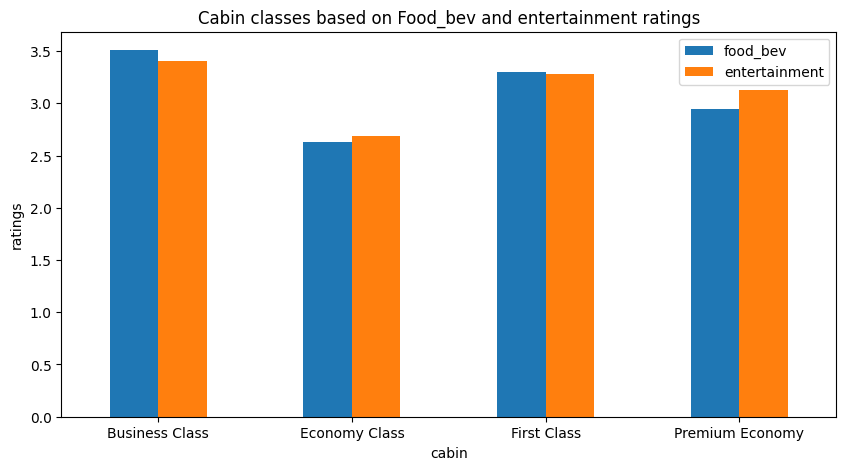

In [64]:
# Chart - 4 visualization code
plt.rcParams['figure.figsize']=(10,5)
eda_4.plot(x="cabin", y=["food_bev", "entertainment"], kind="bar")
plt.title('Cabin classes based on Food_bev and entertainment ratings')
plt.ylabel('ratings')
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

`Side by side Bar Chart` is best suited for showing side by side comparision of various cabin class wrt food_beverages and entertainment.

##### 2. What is/are the insight(s) found from the chart?

We can conclude that there is no significant change in ratings of `food_bev` and `entertainment` in Economy and first_class but in premium economy class there is more rating for entertainment as compared to food_bev and vice-versa for Bussiness_class.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Knowing that there are different preferences for entertainment and food_bev in Premium Economy and Business Class allows the airline to focus on enhancing services in each class selectively. This could involve improving menu options, upgrading entertainment systems, or introducing new features to align with passenger expectations

### Chart 5: Distribution of diffrent types of ratings using `Voilin Plot`

/tmp/ipython-input-66-4019121879.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Rating Category', y='Rating', data=df_melted,palette='Set1')


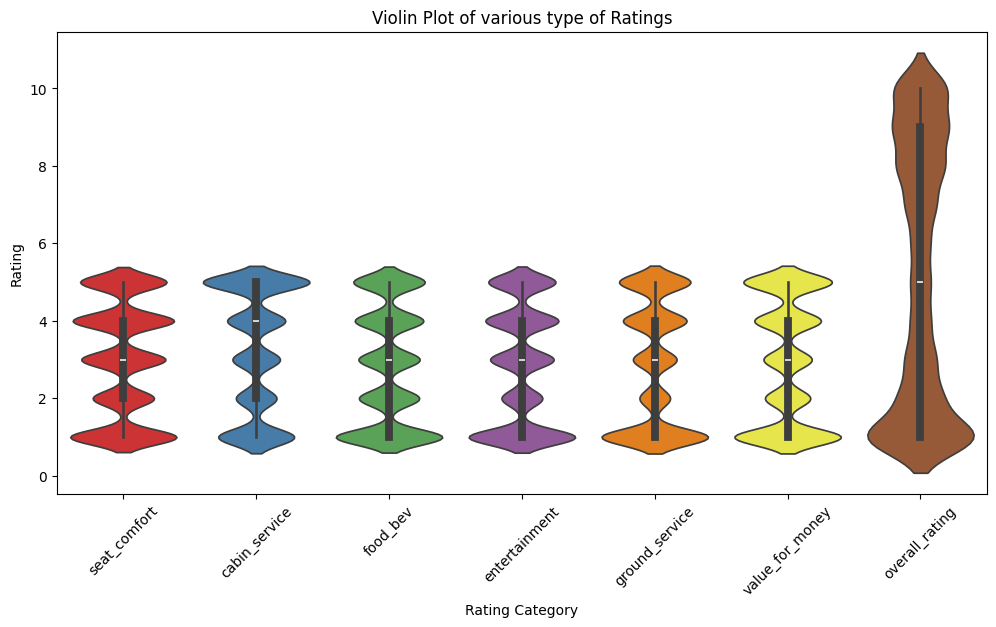

In [66]:
# Chart - 5 visualization code
columns = ['seat_comfort', 'cabin_service', 'food_bev', 'entertainment', 'ground_service', 'value_for_money','overall_rating']

# Melt the DataFrame to long format
df_melted = df.melt(value_vars=columns, var_name='Rating Category', value_name='Rating')

# Create a violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Rating Category', y='Rating', data=df_melted,palette='Set1')
plt.title('Violin Plot of various type of Ratings')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

We chose `Voilin chart` because they are particularly useful for comparing the distribution of data between different groups or categories.This allows us to see not only the average rating for each type but also how ratings are spread out.

##### 2. What is/are the insight(s) found from the chart?

We can see that our mostly rating variables spreds between 1-6 and only `over_all rating` is ranging between 1-10 and mostly ratings are either lower range side or upper range side.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Airlines can use this insight to adjust pricing strategies.If customers rate the value for money lower, airlines can consider offering more competitive pricing or value-added services.hence improving specific aspects of service that are consistently rated lower can enhance the airline's brand reputation and differentiate it from competitors.

### Chart 6 : `Horizontal column chart` for top rated airlines

/tmp/ipython-input-67-459106408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=overall['airline'],x = overall['overall_rating'],palette ="tab10" )


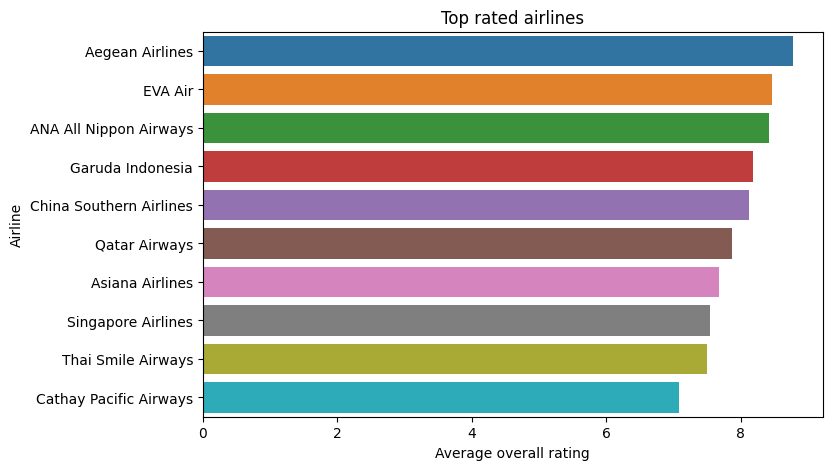

In [67]:
# Chart - 6 visualization code
plt.figure(figsize= (8,5))
overall = df.groupby(df['airline'])['overall_rating'].mean().sort_values(ascending = False).head(10).reset_index()
ax = sns.barplot(y=overall['airline'],x = overall['overall_rating'],palette ="tab10" )
plt.xlabel('Average overall rating')
plt.ylabel('Airline')
plt.title('Top rated airlines')

plt.show()

##### 1. Why did you pick the specific chart?

We picked `horizontal column chart` for comparison of various airlines wrt average overall rating.

##### 2. What is/are the insight(s) found from the chart?

From this chart we can see `Aegean airlines` is highest overall rating followed by `EVA airlines` and `ANA all Nippon Airways` while `Cathay Pecific airways` has the lowest rating .

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Aegean Airlines, EVA Airlines, and ANA All Nippon Airways can continue to focus on providing excellent service to maintain their high ratings. This can include improving in-flight amenities, on-time performance, and customer service.
 Cathay Pacific Airways, being rated lower, can invest in training and development programs for its staff to enhance customer service and improve overall customer experience.

#### Chart - 7: ` Bar chart` for top 10 Airlines wrt to value for money

/tmp/ipython-input-68-1758719981.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=val['airline'],y = val['value_for_money'] ,palette = 'viridis')


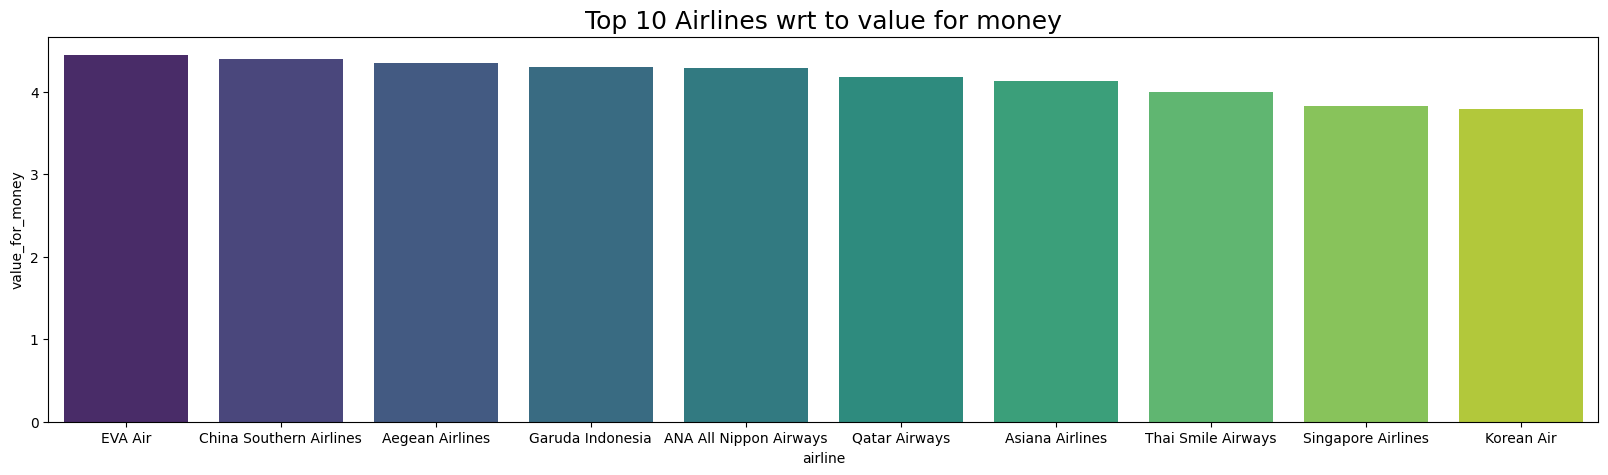

In [68]:
# Chart - 7 visualization code
plt.figure(figsize= (20,5))
val = df.groupby(df['airline'])['value_for_money'].mean().sort_values(ascending = False).head(10).reset_index()
ax = sns.barplot(x=val['airline'],y = val['value_for_money'] ,palette = 'viridis')

plt.title('Top 10 Airlines wrt to value for money',fontsize = 18)
plt.show()

##### 1. Why did you pick the specific chart?

We picked `Bar chart` for comparison of various airlines wrt to Average rating of value for money.

##### 2. What is/are the insight(s) found from the chart?

We can see that `EVA Air ` is the highest rated followed by China Southern Airlines and Aegean Airlines  for value for money .

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Based on the above insightes EVA Air can offer loyalty programs or incentives for frequent flyers to encourage repeat business and enhance customer loyalty.

#### Chart - 8: `Histogram` for Distribution of overall rating

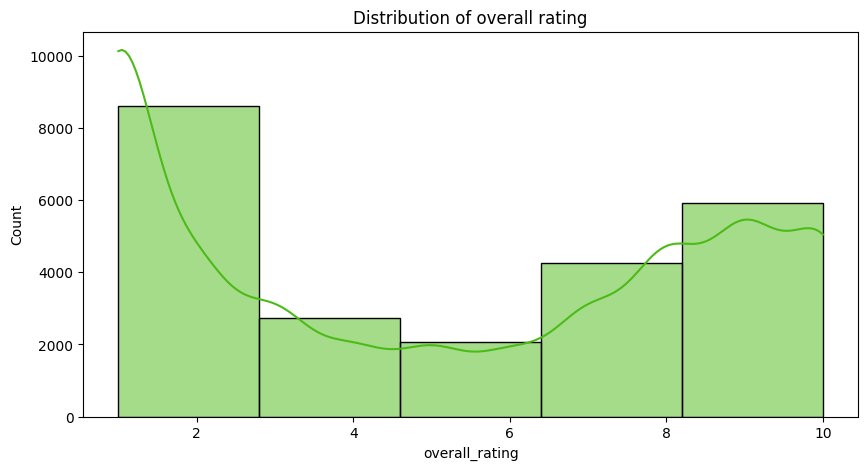

In [69]:
# Chart - 8 visualization
sns.histplot(df['overall_rating'], kde = True,bins =5,color='#4CBB17')
plt.title('Distribution of overall rating')
plt.show()

##### 1. Why did you pick the specific chart?

 We chose `Histogram`  for distribution of Overall rating.

##### 2. What is/are the insight(s) found from the chart?

We can conclude that most people have rated between either 1-2 or 8-10
it shows that passenger have either best or worst experience with airline.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Based on above insightes Airlines can focus on addressing the aspects that lead to extreme negative experiences, such as poor customer service, flight delays, or uncomfortable seating, to reduce the number of low ratings and engaging with customers who have provided extreme ratings (either low or high) can provide valuable feedback for improvement and allow airlines to address specific pain points or areas of excellence.

#### Chart - 9: `Boxplot` for Cabin Class Recommendation based on service ratings

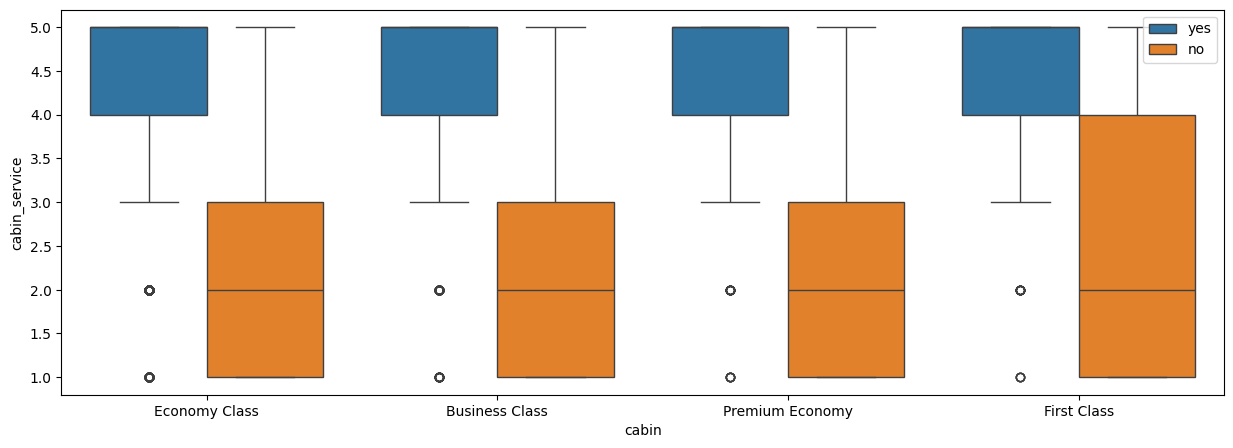

In [70]:
# Chart - 9 visualization code
plt.figure(figsize=(15,5))
sns.boxplot(x=df['cabin'], y=df['cabin_service'], hue = df['recommended'])
plt.legend(loc='upper right')

##### 1. Why did you pick the specific chart?

We picked this type of `Boxplot` to show rating comparison between diffrent cabin classes.

##### 2. What is/are the insight(s) found from the chart?

We can see for every cabin class if the service rating is more then 3 then passenger is more likely to recommend that airline to others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

By focusing on enhancing service quality across all cabin classes to ensure ratings exceed 3, airlines can improve overall customer satisfaction, leading to positive recommendations and repeat business

negative-impact from insights:
If service ratings for any cabin class consistently fall below 3, it could lead to negative word-of-mouth, lower customer satisfaction, and a decline in recommendations, which could result in a loss of customers and revenue.

#### Chart - 10 : `Bar chart` for Number of reviews over months

/tmp/ipython-input-71-2653889326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = df2['month_name'], y = df2['count'],palette = 'Dark2')


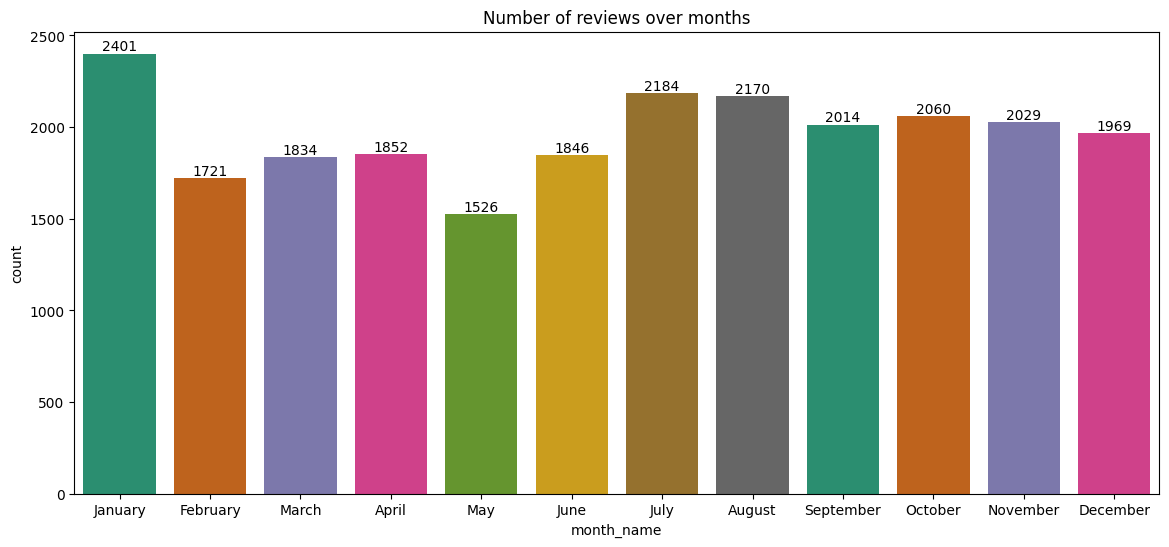

In [71]:
# Chart - 10 visualization code

plt.figure(figsize= (14,6))
plt.title('Number of reviews over months')
df['month_name'] = df['review_date'].dt.strftime('%B')
df['month'] = df['review_date'].dt.month
df2 = df[['month_name','month']].value_counts().reset_index().sort_values(by = 'month')
df2.rename(columns={0:'count'},inplace = True)
ax = sns.barplot(x = df2['month_name'], y = df2['count'],palette = 'Dark2')
for num in ax.containers:
  ax.bar_label(num)
plt.show()

##### 1. Why did you pick the specific chart?

Here we are plotting in which month how many reviews are submitting so with the help of this we can check is there any pattern or relation of number of reviews with the month so the best suited chart is a `bar chart`.

##### 2. What is/are the insight(s) found from the chart?

We can analyze from this chart that `january` month is having a large number of reviews as compared to others follwed by `july` and `august` while in the month of may we have the least may be january is a holiday or vacation month so more number of travellers are there so reviews is also there or the staff is not properly managing the services due to this reviews are more because passenger traffic is more.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

For holiday months if we are having more passenger traffic so we should employ the temporary staff to not spoil our services and management if the traffic is the reason.

#### Chart - 11: `Grouped bar chart` to compare overall rating vs cabin type

<Axes: title={'center': 'Overall rating vs cabin type'}, xlabel='cabin', ylabel='overall_rating'>

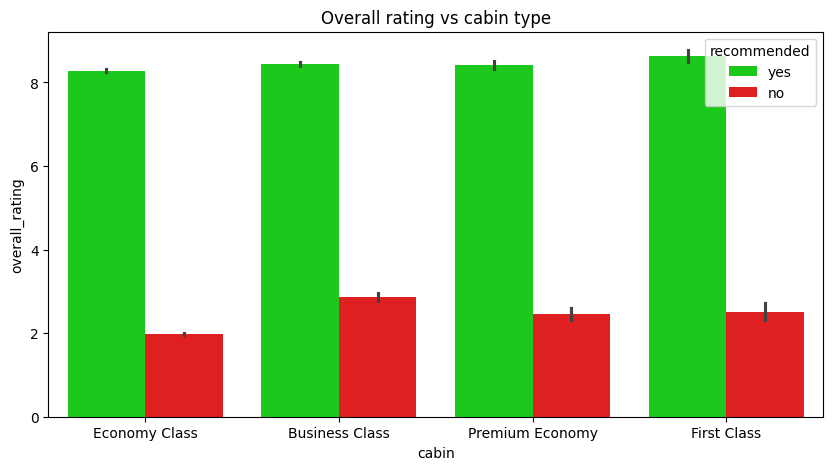

In [72]:
# Chart - 11 visualization code
#Cabin type and overall service ratings (out of 10)
plt.figure(figsize=(10,5))
plt.title('Overall rating vs cabin type')
sns.barplot(x = df.cabin, y = df.overall_rating, hue = df['recommended'], palette= ['#00e500','red'])

##### 1. Why did you pick the specific chart?

Since we are plotting our categorical value against discrete numerical value so best suited chart is a `side by side bar chart`.

##### 2. What is/are the insight(s) found from the chart?

We can clearly see from this that almost in all cabin type we have overall rating more than 8 and the customer recommend the airline to others while for no we have almost 2 rating overall in economy while 3 for rest of all, so there is no much difference between cabin type if we see recommend yes/no .

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We can say from above insights that if a person give overall rating more than 8 then its 99% sure that he is gonna recommend the airline to others by the help of rating we can request our customer to share their opinions on airline service on some platform for recommendation, while if person is not satisfied we will try to resolve their issue with best possible solution.

#### Chart - 12 - Correlation Heatmap

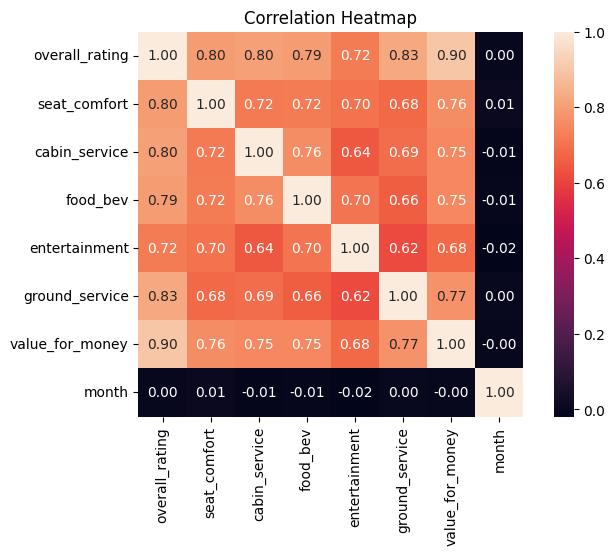

In [76]:
# Correlation Heatmap visualization code
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.title('Correlation Heatmap')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', annot_kws={'size': 10}, vmax=1, square=True, cmap="rocket")
plt.show()

##### 1. Why did you pick the specific chart?

This particular graph is the most powerful visualisation as it depicts the relationship of all the columns with each other and one another too.

##### 2. What is/are the insight(s) found from the chart?

Here on the graph the positive values tell us about that that particular variable is directly proportional to other one corresponding to it , the negative value indicates that the variable is indirectly proportional to corresponding varibale and larger the magnitude , more is the dependency. Also 1 indicates that if you were looking at a heatmap of a variable like value_for_money" plotted on both axes, and you saw a "1" in a cell, it would mean that when the minimum nights is high on the X-axis, it's also high on the Y-axis. When it's low on the X-axis, it's low on the Y-axis, and the relationship between these two instances of value_for_money is very strong and positive.

#### Chart - 13 - Pair Plot

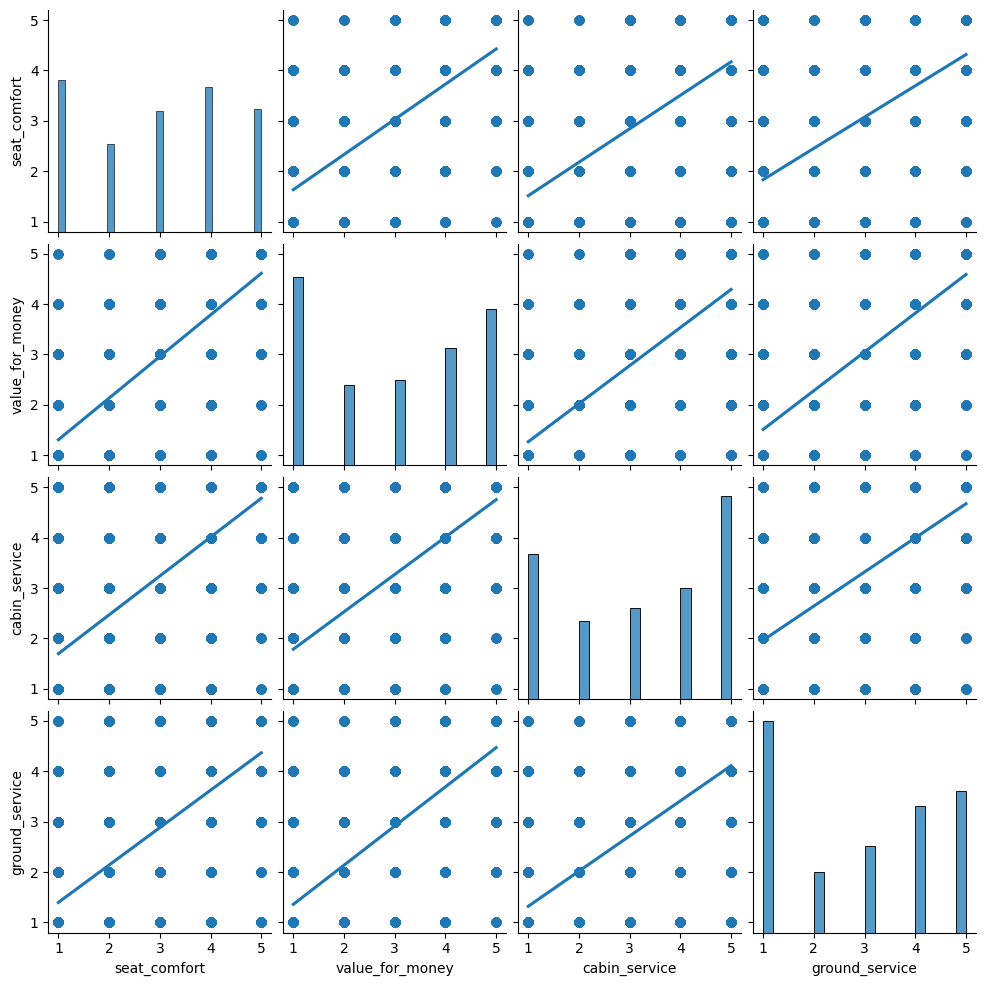

In [77]:
# Pair Plot visualization code
column_name = [ 'seat_comfort','value_for_money','cabin_service','ground_service']
pairplot_data = df[column_name]
chart15=sns.pairplot(pairplot_data,kind = 'reg')
plt.show()

##### 1. Why did you pick the specific chart?

Here we wanted to have a pairwise visualisation of all the columns in the dataset , hence used `pairplot`.

##### 2. What is/are the insight(s) found from the chart?

Since we have a discrete type of dataset so the distribution is showing here is not so perfect but by this we can see a positive relationship between all rating related columns.

# ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* Null Hypothesis (H0): The overall ratings for two specific airlines are equal.


* Alternative Hypothesis (H1): The overall ratings for two specific airlines are not equal.

#### 2. Perform an appropriate statistical test.

In [78]:
# Perform Statistical Test to obtain P-Value

# Calculate the means and standard deviations of the two halves
mean1 = (df[df['airline']=='Qatar Airways']['overall_rating']).mean()
mean2 = (df[df['airline']=='EVA Air']['overall_rating']).mean()
std1 = (df[df['airline']=='Qatar Airways']['overall_rating']).std()
std2 = (df[df['airline']=='EVA Air']['overall_rating']).std()

# Calculate the sample sizes
n1 = (df[df['airline']=='Qatar Airways']['overall_rating']).count()
n2 = (df[df['airline']=='EVA Air']['overall_rating']).count()

#Calculate the standard error for each airline
se1 = std1 / np.sqrt(n1)
se2 = std2 / np.sqrt(n2)

# Calculate the standard error of the difference between means
standard_error = np.sqrt(se1**2 + se2**2)

# Calculate the t_test
t_stat = (mean1 - mean2) / standard_error

#Significance level
alpha = 0.05

#Degree of freedom
dodf = n1 + n2 - 2

#calculating probability point function
cv = stats.t.ppf(1.0 - alpha, dodf)

# Calculate the p-value (two-tailed test)
p_value = (1 - stats.t.cdf(abs(t_stat), dodf)) * 2

# Set the significance level
alpha = 0.05

print('The p value for 0.05 significance level is {:.5f}'.format(p_value))

# Compare the p-value with the significance level
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference in overall rating of two airlines.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in overall rating of two airlines.")

The p value for 0.05 significance level is 0.00019
Reject the null hypothesis. There is a significant difference in overall rating of two airlines.


##### Which statistical test have you done to obtain P-Value?

We performed T-Test for this hypothesis testing to obtain P-value.

##### Why did you choose the specific statistical test?

 We have a sample dataset and we are making inference about population and our population parameters are not known to us and to compare the overall ratings of the two selected airlines.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* Null Hypothesis (H0): There is no association between the traveller type and the likelihood of recommending the airline.


* Alternative Hypothesis (H1): There is an association between the traveller type and the likelihood of recommending the airline.

#### 2. Perform an appropriate statistical test.

In [79]:
# Perform Statistical Test to obtain P-Value
# Create a contingency table
contingency_table = pd.crosstab(df['traveller_type'], df['recommended'])

# Perform chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Output the results
print(f'Chi-square statistic: {chi2}')
print(f'P-value: {p}')
print(f'Degrees of freedom: {dof}')


# Compare the p-value with the significance level
if p_value < alpha:
    print("Reject the null hypothesis. There is an association between the traveller type and the likelihood of recommending the airline.")
else:
    print("Fail to reject the null hypothesis. There is no association between the traveller type and the likelihood of recommending the airline.")

Chi-square statistic: 304.72904284799944
P-value: 9.424196343911983e-66
Degrees of freedom: 3
Reject the null hypothesis. There is an association between the traveller type and the likelihood of recommending the airline.


##### Which statistical test have you done to obtain P-Value?

We performed Chi-square Test for this hypothesis testing to obtain P-value.

##### Why did you choose the specific statistical test?

A chi-square test of independence can be used to assess whether there is a significant relationship between the traveller type and the recommended status.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* Null Hypothesis (H0): The seat comfort ratings are the same across different cabin classes.


* Alternative Hypothesis (H1): There is a significant difference in seat comfort ratings among different cabin classes.

#### 2. Perform an appropriate statistical test.

In [80]:
# Perform Statistical Test to obtain P-Value
# Perform one-way ANOVA
f_statistic, p_value = f_oneway(df['seat_comfort'][df['cabin'] == 'First Class'],
                                df['seat_comfort'][df['cabin'] == 'Business Class'],
                                df['seat_comfort'][df['cabin'] == 'Premium Economy'],
                                df['seat_comfort'][df['cabin'] == 'Economy Class'])

# Set significance level (alpha)
alpha = 0.05


print("\nResults:")
print(f"F-statistic: {f_statistic}")
print(f"P-value: ",p_value)

# Check for statistical significance
if p_value < alpha:
    print("\nResult: Reject the null hypothesis. There is a significant difference in seat comfort ratings.")
else:
    print("\nResult: Fail to reject the null hypothesis. No significant difference in seat comfort ratings.")


Results:
F-statistic: 628.3599335213514
P-value:  0.0

Result: Reject the null hypothesis. There is a significant difference in seat comfort ratings.


##### Which statistical test have you done to obtain P-Value?

We performed One-way ANOVA Test for this hypothesis testing to obtain P-value.

##### Why did you choose the specific statistical test?

A one way ANOVA test is used to compare the means of seat comfort ratings in different cabin classes.

# ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

We have already handled the missing values in exploratory data analysis.

### 2. Handling Outliers

##### What all outlier treatment techniques have you used and why did you use those techniques?

The dataset had no outliers so there was no need of handling as such.

### 3. Categorical Encoding

#### Label Encoding

In [81]:
# Encode your categorical columns
label_encode = LabelEncoder()
df['recommended'] = label_encode.fit_transform(df['recommended'])

#### Ordinal Encoding

In [82]:

ordinal_encoder = ce.OrdinalEncoder(mapping=[{'col': 'cabin', 'mapping': {'Economy Class': 1, 'Business Class': 3,'Premium Economy' : 2,'First Class' :4}}])
df['cabin']= ordinal_encoder.fit_transform(df['cabin'])

#### One hot encoding

In [86]:
import category_encoders as ce

print(df.columns)  # Inspect actual column names

Index(['airline', 'overall_rating', 'review_date', 'traveller_type_1',
       'traveller_type_2', 'traveller_type_3', 'traveller_type_4', 'cabin',
       'departure_date', 'seat_comfort', 'cabin_service', 'food_bev',
       'entertainment', 'ground_service', 'value_for_money', 'recommended',
       'month_name', 'month'],
      dtype='object')


In [89]:
one_hot_encoder = ce.OneHotEncoder(cols=['cabin'])  # use the exact name
df = one_hot_encoder.fit_transform(df)

#### What all categorical encoding techniques have you used & why did you use those techniques?

As we can not give categorical values in machine learning model so we need to encode them with numerical values . Wr have use different techniques of encoding for different columns


For the **"Traveller_Type"** column, which appears to represent categorical data with different types of travelers (e.g., Solo Leisure), it's appropriate to use one-hot encoding. One-hot encoding is commonly used for categorical variables with multiple levels, where each level is treated as a distinct category.

For **"Cabin" column** : There is a clear ordinal relationship, where the different cabin classes have a meaningful and consistent order (e.g., Economy < Premium Economy < Business < First Class), then ordinal encoding could be a suitable choice. In this case, each category is assigned a numerical value based on its order.

For **"recommended"** column : Since we have two categories like "Yes" and "No, we used label encoding. Label encoding involves assigning a numerical label to each unique category. For "Yes" and "No," you could encode them as 1 and 0, respectively.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [90]:
df.drop(columns = ['review_date','month_name','month','departure_date','airline'],inplace = True)

Columns like **'review_date'** and **'departure_date**' represent date or time-related information, which is not directly interpretable by most machine learning algorithms.

Additionally **'month'** and **'month_name'** are the columns that we made for analysis purpose so model do not require to get trained with these so dropping them too.

Column **'airline'** is basically the name of the airline which is again not relevant for the model to get trained on.

#### 2. Feature Selection

In [91]:
df[['overall_rating','seat_comfort','food_bev','cabin_service','entertainment','ground_service','value_for_money','recommended']].corr()

,overall_rating,seat_comfort,food_bev,cabin_service,entertainment,ground_service,value_for_money,recommended
overall_rating,1.000000,0.795892,0.793299,0.802345,0.720355,0.826567,0.899440,0.899921
seat_comfort,0.795892,1.000000,0.720664,0.715203,0.698042,0.678297,0.758516,0.725536
food_bev,0.793299,0.720664,1.000000,0.759962,0.704976,0.655019,0.747458,0.729327
cabin_service,0.802345,0.715203,0.759962,1.000000,0.643760,0.686711,0.748290,0.742769
entertainment,0.720355,0.698042,0.704976,0.643760,1.000000,0.615235,0.679103,0.648191
ground_service,0.826567,0.678297,0.655019,0.686711,0.615235,1.000000,0.772872,0.755555
value_for_money,0.899440,0.758516,0.747458,0.748290,0.679103,0.772872,1.000000,0.839698
recommended,0.899921,0.725536,0.729327,0.742769,0.648191,0.755555,0.839698,1.000000


In [92]:
# Drop the overall ratings because of data leakage
df.drop('overall_rating',axis = 1 ,inplace = True)

##### What all feature selection methods have you used  and why?

Feature selection is the process of choosing a subset of relevant features (variables, predictors) for use in model construction

We basically used **filter method** which evaluate the relevance of features based on statistical measures or scores calculated independently of the machine learning algorithm.

Here we used **Correlation coefficient** that Measures the linear relationship between two variables. Features with high correlation to the target variable or with other features may be considered redundants and so is the reason we dropped overall_rating column.

##### Which all features you found important and why?

All these features are important `seat comfort`, `food_bev`, `entertainment`, `ground_service`, `value for money`, `cabin service` because all these columns helps us in prediction of our referal model.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

There is no need of feature transformation since we have discrete values in our data and it has values in the same range.

### 6. Data Scaling

#### Do you think that your data needs to be scaled? If yes, which scaling technique have you used. Explain Why?


Scaling data is used to standardize the range of independent variables or features. It's particularly useful when features have different scales or units of measurement, and here the features are on the same scale so there is no need of scaling.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is a technique commonly used in machine learning and data analysis to reduce the number of features or variables in a dataset while preserving its essential information. This reduction can help alleviate computational expenses, improve model performance, and mitigate the curse of dimensionality.

In [94]:
# DImensionality Reduction (If needed)
pca = PCA()
airline_pca = pca.fit_transform(df.iloc[:,:-1])

# Convert PCA components to a DataFrame for better readability
airline_pca_df = pd.DataFrame(data=airline_pca, columns=[f'PC{i+1}' for i in range(len(df.iloc[:,:-1].columns))])

# Display the first few rows of the PCA components
airline_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,2.097169,-1.466512,1.115673,0.309863,-0.129254,0.757541,-0.249681,-0.170419,-0.493847,0.896860,-0.008186,-0.027716,-3.774758e-15,2.220446e-16
1,-3.664164,-0.278949,-0.353157,2.378210,-0.335293,-0.777764,0.382081,-0.774552,-0.557206,-0.441552,-0.053599,-0.036496,2.775558e-15,-2.220446e-16
2,-2.365655,-0.805627,0.684635,-1.106806,-1.383004,1.561236,-0.488527,0.231178,-0.513530,0.771752,-0.031808,0.003131,-3.663736e-15,2.775558e-16
3,4.581313,-0.053802,-0.238807,-0.891413,0.407127,0.206267,0.727974,0.157951,0.080729,0.142280,-0.029422,-0.008307,-2.331468e-15,5.551115e-17
4,-4.805821,0.135261,-0.111463,-0.075944,0.305044,0.079332,0.650662,0.475673,0.140739,-0.023688,-0.031714,0.004695,-1.110223e-16,-3.330669e-16


PCA is a dimensionality reduction technique commonly used to reduce the number of dimensions in a dataset while preserving as much variance as possible. It achieves this by transforming the original features into a new set of orthogonal (uncorrelated) features called principal components.

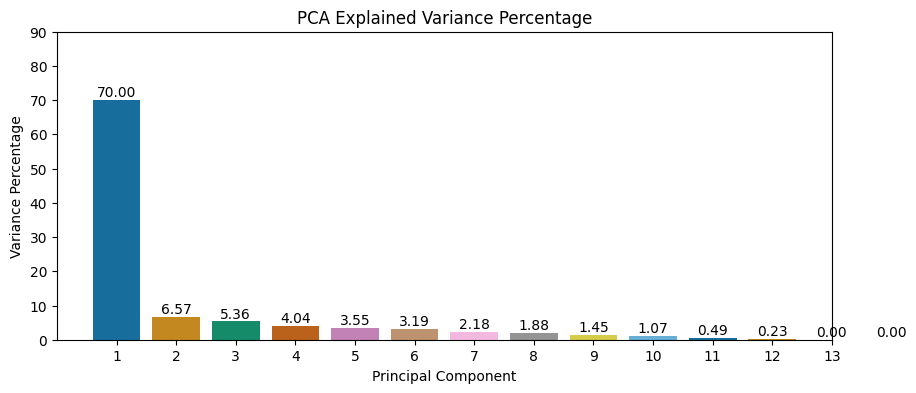

In [95]:
explained_variance = pca.explained_variance_ratio_

# Plotting the explained variance
plt.figure(figsize=(10, 4))
op=sns.barplot(x=range(1, len(explained_variance) + 1), y=explained_variance*100, hue=range(1, len(explained_variance) + 1),palette='colorblind',legend=False)
plt.ylabel('Variance Percentage')
plt.xlabel('Principal Component')
plt.title('PCA Explained Variance Percentage')
for i, num in enumerate(explained_variance):
    op.text(i, num * 100+1, f'{num*100:.2f}',ha='center')
plt.ylim(0 , 90)
plt.xlim(-1 , 12)
plt.show()

In the context of Principal Component Analysis (PCA), explained_variance_ratio_ is an attribute of the PCA object that represents the amount of variance explained by each of the principal components.. This ratio indicates the proportion of the dataset's variance that lies along the corresponding principal component axis.

In [96]:
pca.explained_variance_ratio_

array([7.00049135e-01, 6.56526652e-02, 5.36206684e-02, 4.03524272e-02,
       3.54711533e-02, 3.18585221e-02, 2.17674682e-02, 1.87666577e-02,
       1.44836046e-02, 1.07493222e-02, 4.92261919e-03, 2.30575687e-03,
       7.51429873e-17, 0.00000000e+00])

In [97]:
for i in range(1,len(explained_variance)):
  print(f'Sum of percentage of variance of {i} columns',round(sum(explained_variance[0:i]*100),2))

Sum of percentage of variance of 1 columns 70.0
Sum of percentage of variance of 2 columns 76.57
Sum of percentage of variance of 3 columns 81.93
Sum of percentage of variance of 4 columns 85.97
Sum of percentage of variance of 5 columns 89.51
Sum of percentage of variance of 6 columns 92.7
Sum of percentage of variance of 7 columns 94.88
Sum of percentage of variance of 8 columns 96.75
Sum of percentage of variance of 9 columns 98.2
Sum of percentage of variance of 10 columns 99.28
Sum of percentage of variance of 11 columns 99.77
Sum of percentage of variance of 12 columns 100.0
Sum of percentage of variance of 13 columns 100.0


In [98]:
pca_2 = PCA(n_components=6)
airline_pca_2 = pca_2.fit_transform(df.iloc[:,:-1])

# Shape after reduction
print("Original Shape:", df.iloc[:,:-1].shape)
print("Transformed Shape:", airline_pca_2.shape)

Original Shape: (23606, 14)
Transformed Shape: (23606, 6)


Deciding the number of components (or principal components) to retain in Principal Component Analysis (PCA) involves balancing the trade-off between dimensionality reduction and the amount of variance preserved.

By plotting **Cumulative explained variance** we understood the cumulative explained variance ratio as a function of the number of components. Decided   on the number of components that explains a large portion of the variance in the data (approx 90%) to 6 components. This method provides a threshold for retaining components while preserving most of the information in the original dataset.

In [99]:
airline_pca_2_df = pd.DataFrame(data=airline_pca_2, columns=[f'PC{i+1}' for i in range(len(df.iloc[:,:6].columns))])

In [100]:
airline_pca_2_df.head(3)

,PC1,PC2,PC3,PC4,PC5,PC6
0,2.097169,-1.466512,1.115673,0.309863,-0.129254,0.757541
1,-3.664164,-0.278949,-0.353157,2.378210,-0.335293,-0.777764
2,-2.365655,-0.805627,0.684635,-1.106806,-1.383004,1.561236


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

We used `Principal Component Analysis` (PCA) reducing the number of columns from 11 to 6, you effectively decreased the dimensionality of your dataset while retaining 90% of its essence. This means that the six remaining columns contain the most important information or capture the majority of the variability present in the original dataset

### 8. Data Splitting

In [101]:
# Split your data to train and test. Choose Splitting ratio wisely.
x = airline_pca_2_df
y = df.iloc[:,-1]

In [102]:
x

,PC1,PC2,PC3,PC4,PC5,PC6
0,2.097169,-1.466512,1.115673,0.309863,-0.129254,0.757541
1,-3.664164,-0.278949,-0.353157,2.378210,-0.335293,-0.777764
2,-2.365655,-0.805627,0.684635,-1.106806,-1.383004,1.561236
3,4.581313,-0.053802,-0.238807,-0.891413,0.407127,0.206267
4,-4.805821,0.135261,-0.111463,-0.075944,0.305044,0.079332
...,...,...,...,...,...,...
23601,-4.826975,0.113828,-0.139447,-0.088060,0.280488,0.047932
23602,-4.406957,0.124944,0.518565,-0.298434,-0.272394,0.248592
23603,3.710700,-0.531531,0.633046,0.283821,0.077370,-0.588243
23604,-4.805821,0.135261,-0.111463,-0.075944,0.305044,0.079332


In [103]:
y

,recommended
0,1
1,0
2,0
3,1
4,0
...,...
23601,0
23602,0
23603,1
23604,0


* Here we are using `Hold-Out-Approach` for data splitting i.e. (Train-Test Split).

In [104]:
#Splitting the datset
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

* Here we are checking the no. of rows and columns of every splitted datasets.

In [105]:
#Shape of splitted datasets
print('Shape of X_train',X_train.shape)
print('Shape of y_train',y_train.shape)
print('Shape of X_test',X_test.shape)
print('Shape of y_test',y_test.shape)

Shape of X_train (16524, 6)
Shape of y_train (16524,)
Shape of X_test (7082, 6)
Shape of y_test (7082,)


##### What data splitting ratio have you used and why?

The most typical data splitting ratio is the 70-30 or 80-20 split, where the dataset is divided into a training set and a test set. The training set is used to train the model, while the test set is used to evaluate its performance.

We used 70-30 Split: in this ratio, 70% of the data is usually allocated to the training set, while the remaining 30% is allocated to the test set. This split allows the model to learn from the majority of the data while still having a substantial portion reserved for evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

An imbalanced dataset refers to a dataset where the distribution of classes (or categories) is not uniform. In other words, one class or category has significantly more instances (samples) than the other class or classes. In this case the classes are somewhat uniform so no need of handling.

In [106]:
# Handling Imbalanced Dataset (If needed)
y.value_counts()

,count
recommended,
0,12338
1,11268


# ***7. ML Model Implementation***

### ML Model - 1 - Decision Tree

* Fit the model on training and prediction on testing dataset.

In [107]:
# ML Model - 1 Implementation

model = DecisionTreeClassifier()

# Fit the Algorithm

model.fit(X_train, y_train)

# Predict on the model

prediction = model.predict(X_test)

* Checking the evaluation metrices on test data.

In [108]:
#Checking the evaluation metrices on test data
print("Accuracy on test data:", accuracy_score(y_test, prediction))
print("Precision on test data:", precision_score(y_test, prediction))
print("Recall on test data:", recall_score(y_test, prediction))
print("F1_score on test data:", f1_score(y_test, prediction))

Accuracy on test data: 0.9138661395086134
Precision on test data: 0.9172619047619047
Recall on test data: 0.9027533684827183
F1_score on test data: 0.9099498080897549


* Fit the model on training data and prediction on training data dataset.

In [109]:
# ML Model - 1 Implementation

model1 = DecisionTreeClassifier()

# Fit the Algorithm

model1.fit(X_train, y_train)

# Predict on the model

prediction1 = model1.predict(X_train)

* Checking the evaluation metrices on training data.

In [110]:
#Checking the evaluation metrices on training data
print("Accuracy on training data:", accuracy_score(y_train, prediction1))
print("Precision on training data:", precision_score(y_train, prediction1))
print("Recall on training data:", recall_score(y_train, prediction1))
print("F1_score on training data:", f1_score(y_train, prediction1))

Accuracy on training data: 0.9891672718470104
Precision on training data: 0.9943320881102666
Recall on training data: 0.9828113063407181
F1_score on training data: 0.9885381315233399


* Here we are making two variables to get the f1 score of training and test data.

In [111]:
#variables for training and testing f1 score
f1_dt_test = f1_score(y_test, prediction)
f1_dt_train = f1_score(y_train, prediction1)

* Making a dataframe on these two variables.

In [112]:
# Making a dataframe
dt_df= pd.DataFrame([{'Decision_Tree_Test':f1_dt_test,'Decision_Tree_Train':f1_dt_train}])

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

* Here we are using a Supervised algorithm Decision Tree for the classification of airline passenger recoomendation for predicting the user will recommend or not recommend the airline according to their flight experience.


* Decision tree is good for explainability but it's not that well suited for prediction but in the end we will compare this model with models so we can get the jist how's it performed on our dataset.


* Plot a visulaization graph for comapring f1 score of training and test.

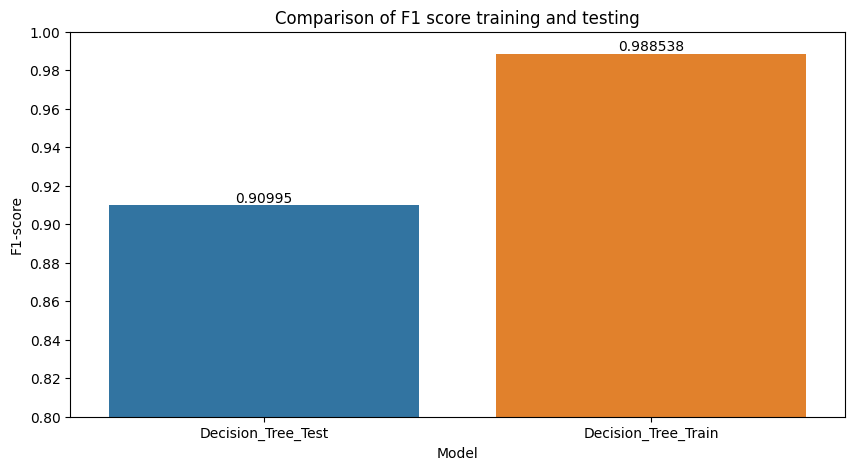

In [113]:
# Visualizing evaluation Metric Score chart
graph=sns.barplot(dt_df)
for bar in graph.containers:
  graph.bar_label(bar)
plt.title('Comparison of F1 score training and testing')
plt.ylim(0.8,1)
plt.yticks([i/100 for i in range(80,102,2)])
plt.xlabel('Model')
plt.ylabel('F1-score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [115]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
dt_classifier = DecisionTreeClassifier()

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# Fit the Algorithm
grid_search = GridSearchCV(dt_classifier, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# Predict on the
best_params = grid_search.best_params_

* To get the best parameter after performing cross validation and hyperparameter tuning like `Grid serach CV`.

In [116]:
#Check for best parameter
best_params

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 10}

* Here we are again fiiting the model on training data and check prediction on testing data with the best parameter that we got from CV and hyperparameter tuning.

In [117]:
#Model Implementataion

best_dt_classifier = DecisionTreeClassifier(**best_params)

#Fit the model

best_dt_classifier.fit(X_train, y_train)

#Predict on the model
prediction2 = best_dt_classifier.predict(X_test)

* Checking evaluation metrices on test data after CV and hyperparameter tuning.

In [118]:
#Checking the evaluation metrices on test data
print("Accuracy on test data:", accuracy_score(y_test, prediction2))
print("Precision on test data:", precision_score(y_test, prediction2))
print("Recall on test data:", recall_score(y_test, prediction2))
print("F1_score on test data:", f1_score(y_test, prediction2))

Accuracy on test data: 0.9329285512567072
Precision on test data: 0.9393124065769806
Recall on test data: 0.9203280609256005
F1_score on test data: 0.9297233318538245


* Here we are again fiiting the model on training data and check prediction on training data with the best parameter that we got from CV and hyperparameter tuning.

In [119]:
#Model Implementataion

best_dt_classifier1 = DecisionTreeClassifier(**best_params)

#Fit the model

best_dt_classifier1.fit(X_train, y_train)

#Predict on the model
prediction3 = best_dt_classifier1.predict(X_train)

* Checking evaluation metrices on training data after CV and hyperparameter tuning.

In [120]:
#Checking the evaluation metrices on test data
print("Accuracy on test data:", accuracy_score(y_train, prediction3))
print("Precision on test data:", precision_score(y_train, prediction3))
print("Recall on test data:", recall_score(y_train, prediction3))
print("F1_score on test data:", f1_score(y_train, prediction3))

Accuracy on test data: 0.9421447591382232
Precision on test data: 0.9475733194913055
Recall on test data: 0.9297173414820473
F1_score on test data: 0.9385604113110539


* Making a confusion matrix to get an idea how well our model predicticed.

[Text(0, 0.5, 'Recommended'), Text(0, 1.5, 'Not Recommend')]

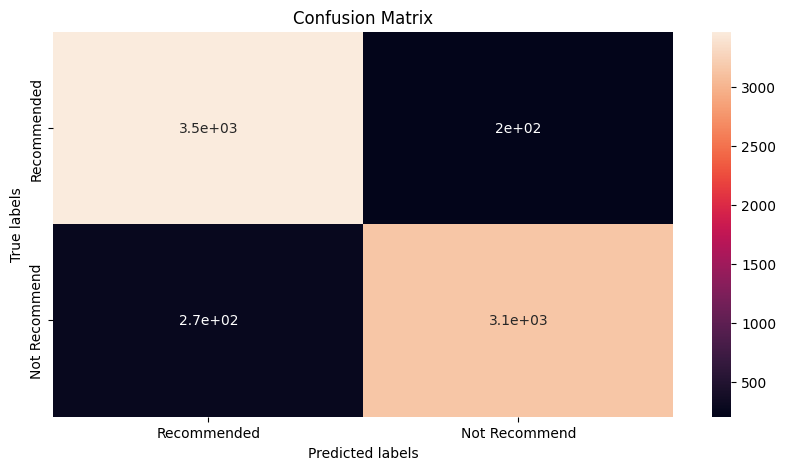

In [122]:
#Plot the matrix
cfu = confusion_matrix(y_test, prediction2)
ax= plt.subplot()
labels = ['Recommended', 'Not Recommend']
sns.heatmap(cfu, annot=True, ax = ax) #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)

* Here we can see that `False negative` is approx 230 and `False Positive` is approx 230.

* Making two variables to get the f1 score of both taraining data and testing dta and make a dataframe.

In [123]:
#variables for training and testing f1 score and make a dataframe
f1_dt_test_hyp = f1_score(y_test, prediction2)
f1_dt_train_hyp = f1_score(y_train, prediction3)
dt_df_hyp = pd.DataFrame([{'Decision_Tree_Test_Hyp':f1_dt_test_hyp,'Decision_Tree_Train_Hyp':f1_dt_train_hyp}])


* Plot a visulaization graph for comapring f1 score of training and test.

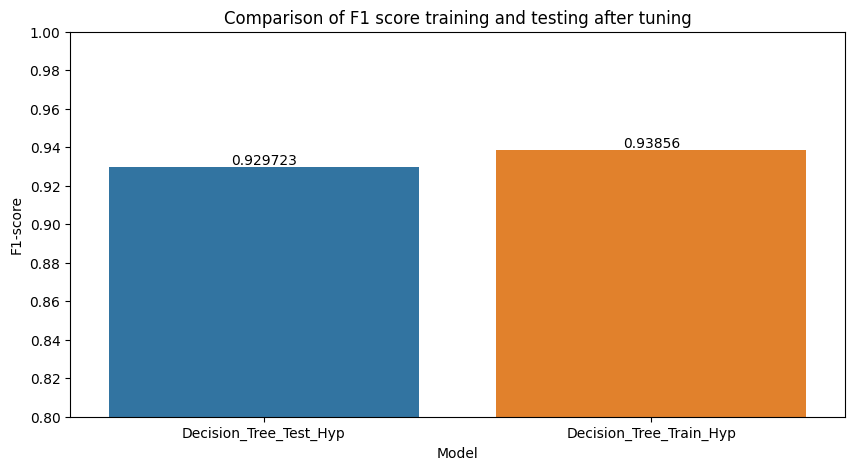

In [124]:
# Visualizing evaluation Metric Score chart
graph1=sns.barplot(dt_df_hyp)
for bar in graph1.containers:
  graph1.bar_label(bar)
plt.title('Comparison of F1 score training and testing after tuning')
plt.ylim(0.8,1)
plt.yticks([i/100 for i in range(80,102,2)])
plt.xlabel('Model')
plt.ylabel('F1-score')
plt.show()

##### Which hyperparameter optimization technique have you used and why?

We used here `GridSeachCV` to get the best parameter of that model because we want an exhaustive search to get those parameter which works best on this model and also we want to try all possible combinations, despite knowing that it takes more computational time we want to experiment this technique so we pass less number of sample space to each parameter so it can execute fast.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, surely we saw the improvement after cross validation and hyperparamter tuning `before cross-validation and hyperparameter tuning` the F1 score on `test data is 0.90` and on `training data is 0.98` so clearly this type of values is shown overfitting issue on training data, but `after cross-validation and hyperparameter tuning` we can see that the F1 score on `test data is 0.932` and on `training data is 0.938`, by this we can see that we are able to minimize the overfitting issue by using cross-validation and hyperparameter tuning.

### ML Model - 2 : KNN

*    Fit the model on training and prediction on testing dataset.








In [125]:
knn = KNeighborsClassifier()

# Train the classifier
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn.predict(X_test)

*   Checking the evaluation metrices on test data.

In [126]:
print("Accuracy on test data:", accuracy_score(y_test, y_pred_knn))
print("Precision on test data:", precision_score(y_test, y_pred_knn))
print("Recall on test data:", recall_score(y_test, y_pred_knn))
print("F1_score on test data:", f1_score(y_test,y_pred_knn))

Accuracy on test data: 0.9299632872070037
Precision on test data: 0.9293702177751618
Recall on test data: 0.9250146455770357
F1_score on test data: 0.9271873165002936


*   Fit the model on training and prediction on testing dataset.

In [127]:
knn1 = KNeighborsClassifier()

# Train the classifier
knn1.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn1 = knn1.predict(X_train)

*   Checking the evaluation metrices on training data.

In [128]:
print("Accuracy on training data:", accuracy_score(y_train, y_pred_knn1))
print("Precision on training data:", precision_score(y_train, y_pred_knn1))
print("Recall on training data:", recall_score(y_train, y_pred_knn1))
print("F1_score on training data:", f1_score(y_train,y_pred_knn1))

Accuracy on training data: 0.9496489954006294
Precision on training data: 0.9500128172263522
Recall on training data: 0.9437229437229437
F1_score on training data: 0.9468574348492591


*   Here we are making two variables to get the f1 score of training and test data.

In [129]:
f1_knn_test = f1_score(y_test,y_pred_knn)
f1_knn_train = f1_score(y_train,y_pred_knn1)

*   Making a dataframe on these two variables.

In [130]:
knn_df= pd.DataFrame([{'Knn_Test':f1_knn_test,'Knn_Train':f1_knn_train}])

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

*   We have used KNN (K Nearest Neighbors) model which is suitable model for classification as well as regression of Supervised ML .

*   The underlying concept of k-NN is intuitive and easy to understand. It relies on the assumption that similar data points tend to belong to the same class.
k-NN doesn't have an explicit training step. Instead, it stores all the training data points in memory. This makes the training process fast and efficient, especially for small to medium-sized datasets.

*   Plotting the visualization of matrices:

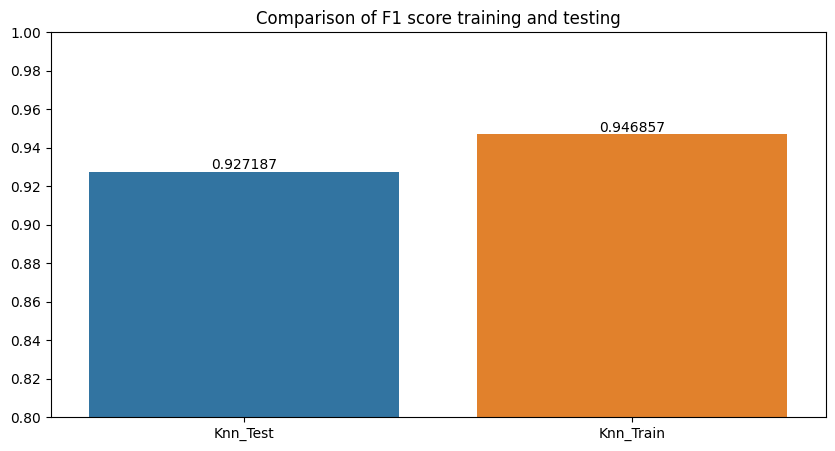

In [131]:
knn_grf=sns.barplot(knn_df)
for bar in knn_grf.containers:
  knn_grf.bar_label(bar)
plt.title('Comparison of F1 score training and testing')
plt.ylim(0.8,1)
plt.yticks([i/100 for i in range(80,102,2)])
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

*   Applying GridSearchSerachCV for getting best hyperparameters

In [132]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Weighting scheme
    'metric': ['euclidean', 'manhattan']  # Distance metric
}

# Instantiate the KNN classifier
knn = KNeighborsClassifier()

# Instantiate GridSearchCV
grid_search1 = GridSearchCV(knn, param_grid, cv=5, scoring='f1')

# Fit GridSearchCV to the training data
grid_search1.fit(X_train, y_train)

# Retrieve the best parameters and best score
best_params = grid_search1.best_params_
best_score = grid_search1.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

# Evaluate the best model on the testing set
best_model = grid_search1.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test Set Score:", test_score)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best Score: 0.9339979364386597
Test Set Score: 0.9339169726066083


*   To get the best parameter after performing cross validation and hyperparameter tuning like Grid serach CV.

In [133]:
curr_parm_knn = best_model.get_params()
curr_parm_knn

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'euclidean',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 9,
 'p': 2,
 'weights': 'uniform'}

*   Here we are again fiiting the model on training data and check prediction on testing data with the best parameter that we got from CV and hyperparameter tuning.

In [134]:
knn1_hy = KNeighborsClassifier(**curr_parm_knn)

# Train the classifier
knn1_hy.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn1_hy = knn1_hy.predict(X_test)

*   Checking evaluation metrices on testing data after tuning

In [135]:
print("Accuracy on test data:", accuracy_score(y_test,y_pred_knn1_hy))
print("Precision on test data:", precision_score(y_test, y_pred_knn1_hy))
print("Recall on test data:", recall_score(y_test, y_pred_knn1_hy))
print("F1_score on test data:", f1_score(y_test,y_pred_knn1_hy))

Accuracy on test data: 0.9339169726066083
Precision on test data: 0.9301985981308412
Recall on test data: 0.9329232571763327
F1_score on test data: 0.9315589353612167


*   Here we are again fiiting the model on training data and check prediction on testing data with the best parameter that we got from CV and hyperparameter tuning.

In [136]:
knn1_hy1 = KNeighborsClassifier(**curr_parm_knn)

# Train the classifier
knn1_hy1.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn1_hy1 = knn1_hy1.predict(X_train)

*   Checking evaluation metrices on training data after tuning

In [137]:
print("Accuracy on training data:", accuracy_score(y_train, y_pred_knn1_hy1))
print("Precision on training data:", precision_score(y_train, y_pred_knn1_hy1))
print("Recall on training data:", recall_score(y_train, y_pred_knn1_hy1))
print("F1_score on training data:", f1_score(y_train,y_pred_knn1_hy1))

Accuracy on training data: 0.9458968772694263
Precision on training data: 0.9462682739163888
Recall on training data: 0.9395212630506748
F1_score on training data: 0.9428826986966522


*   Making a confusion matrix to get an idea how well our model predicticed.

[Text(0, 0.5, 'Recommended'), Text(0, 1.5, 'Not Recommend')]

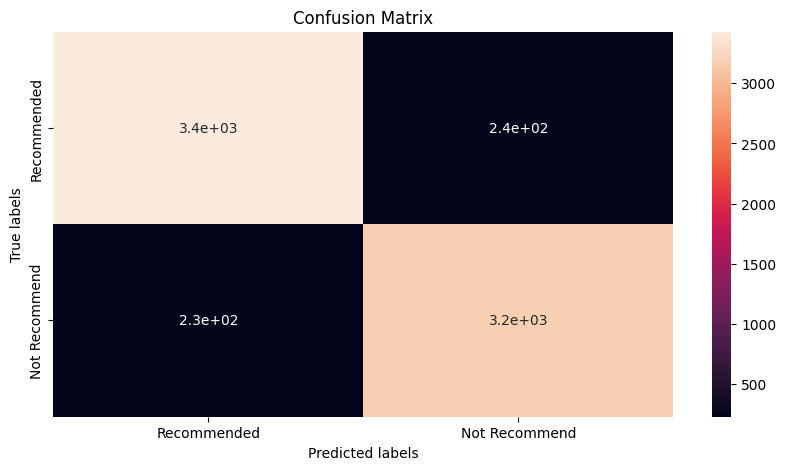

In [138]:
cfu1 = confusion_matrix(y_test, y_pred_knn1_hy)
ax= plt.subplot()
labels = ['Recommended', 'Not Recommend']
sns.heatmap(cfu1, annot=True, ax = ax) #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)

*   From the confusion matrix we can say our model is predicting 233 False Positive and 228 False Negative.

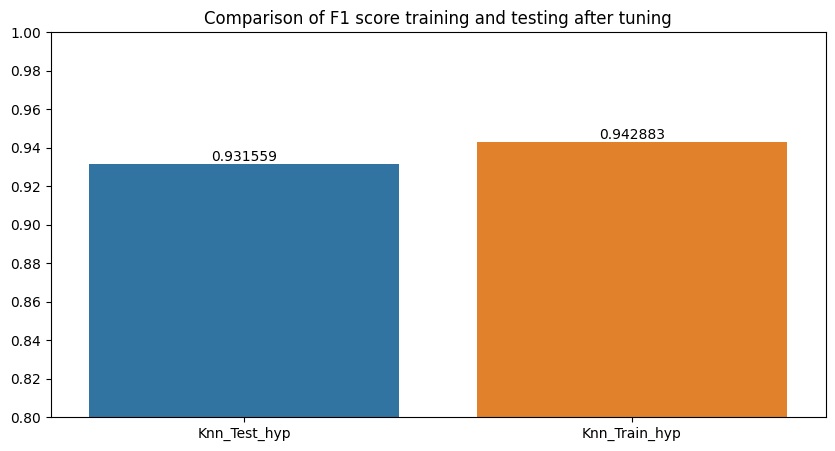

In [139]:
f1_knn_test_hyp = f1_score(y_test,y_pred_knn1_hy)
f1_knn_train_hyp = f1_score(y_train,y_pred_knn1_hy1)
knn_df_hyp= pd.DataFrame([{'Knn_Test_hyp':f1_knn_test_hyp,'Knn_Train_hyp':f1_knn_train_hyp}])
knn_grf_hyp=sns.barplot(knn_df_hyp)
for bar in knn_grf_hyp.containers:
  knn_grf_hyp.bar_label(bar)
plt.title('Comparison of F1 score training and testing after tuning')
plt.ylim(0.8,1)
plt.yticks([i/100 for i in range(80,102,2)])
plt.show()

##### Which hyperparameter optimization technique have you used and why?

*   We used here GridSeachCV to get the best parameter of that model because we want an exhaustive search to get those parameter which works best on this model and also we want to try all possible combinations, despite knowing that it takes more computational time we want to experiment this technique so we pass less number of sample space to each parameter so it can execute fast.



##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Yes, we saw the improvement after cross validation and hyperparamter tuning before cross-validation and hyperparameter tuning the F1 score on test data is 0.92 and on training data is 0.94 so there was a bit of overfitting issue on training data, but after cross-validation and hyperparameter tuning we can see that the F1 score on test data is 0.932 and on training data is 0.938, by this we can see that we are able to minimize the overfitting issue by using cross-validation and hyperparameter tuning.

### ML Model - 3 : SVM

* We are Fitting our model on training data and predict on test data

In [140]:
# ML Model - 3 Implementation

# Fit the Algorithm
svm_model = SVC(kernel='rbf', gamma = 'auto', random_state=42)
svm_model.fit(X_train,y_train)

# Predict on the model
pred_svm = svm_model.predict(X_test)


* Checking evaluation metrices on testing data

In [141]:
print("Accuracy on test data:", accuracy_score(y_test, pred_svm))
print("Precision on test data:", precision_score(y_test, pred_svm))
print("Recall on test data:", recall_score(y_test, pred_svm))
print("F1_score on test data:", f1_score(y_test,pred_svm))

Accuracy on test data: 0.9416831403558317
Precision on test data: 0.9430174195453204
Recall on test data: 0.9355594610427651
F1_score on test data: 0.9392736362299662


* Now we fitting our model with training data and predicting on train data

In [142]:
pred_svm1 = svm_model.predict(X_train)

* Checking evaluation metrices on training data

In [143]:
print("Accuracy on training data:", accuracy_score(y_train, pred_svm1))
print("Precision on training data:", precision_score(y_train, pred_svm1))
print("Recall on training data:", recall_score(y_train, pred_svm1))
print("F1_score on training data:", f1_score(y_train,pred_svm1))

Accuracy on training data: 0.9451101428225611
Precision on training data: 0.9473277527366387
Recall on training data: 0.9365928189457601
F1_score on training data: 0.941929701005186


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer :

* We have used SVM (`Support Vector Machine`) model which is best suitable model for classification of Supervised ML and SVMs tend to generalize well and are less prone to overfitting, especially in high-dimensional spaces.

* SVMs provide control over the trade-off between achieving a low training error and minimizing the complexity of the decision boundary, allowing us to avoid overfitting.

* Plotting the visualization of matrices:


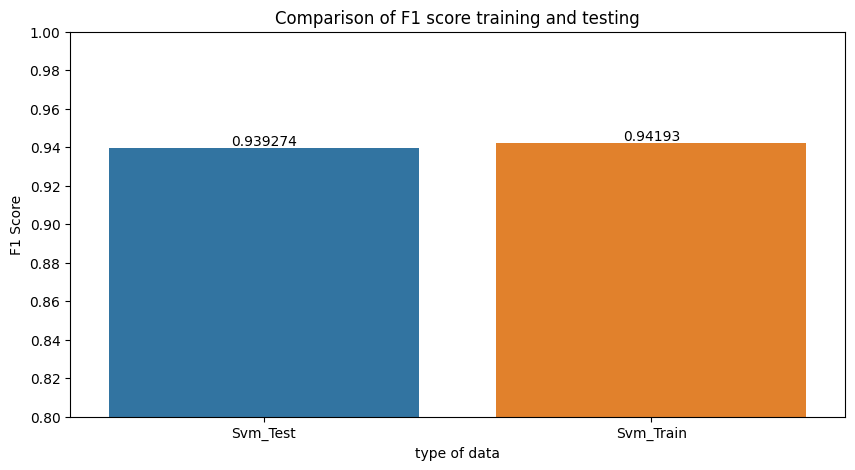

In [144]:
# Plotting the visualization of matrices
f1_svm_test = f1_score(y_test,pred_svm)
f1_svm_train = f1_score(y_train,pred_svm1)
svm_df= pd.DataFrame([{'Svm_Test':f1_svm_test,'Svm_Train':f1_svm_train}])
svm_grf=sns.barplot(svm_df)
for bar in svm_grf.containers:
  svm_grf.bar_label(bar)
plt.title('Comparison of F1 score training and testing')
plt.xlabel('type of data')
plt.ylabel('F1 Score')
plt.ylim(0.8,1)
plt.yticks([i/100 for i in range(80,102,2)])
plt.show()


From above Matrix we can see that our F1 Score is 93% on test data and 94%  on train data so it suggests our model is performing very good on both training and testing data.

#### 2. Cross- Validation & Hyperparameter Tuning

* Applying RandomSerachCV for getting best hyperparameters

In [146]:


# Define the parameter grid to search
param_grid_svm = {'C': [0.1, 1, 10],  # Regularization parameter
              'gamma': [0.001, 0.01, 0.1, 1],  # Kernel coefficient (only for RBF kernel)
              'kernel': ['linear', 'rbf']}  # Kernel type

# Create an SVM model
svm_model = SVC()

# Perform grid search with 5-fold cross-validation
random_search = RandomizedSearchCV(svm_model, param_grid_svm,verbose=2,random_state = 42 ,cv=5,scoring='f1')
random_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params_svm = random_search.best_params_
print("Best Hyperparameters:", best_params)

# Get the best SVM model
best_svm_model = random_search.best_estimator_

# Evaluate the best model on the test set
y_pred_svm = best_svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ....................C=1, gamma=0.001, kernel=linear; total time=   1.7s
[CV] END ....................C=1, gamma=0.001, kernel=linear; total time=   2.3s
[CV] END ....................C=1, gamma=0.001, kernel=linear; total time=   2.5s
[CV] END ....................C=1, gamma=0.001, kernel=linear; total time=   1.8s
[CV] END ....................C=1, gamma=0.001, kernel=linear; total time=   1.6s
[CV] END ...................C=10, gamma=0.001, kernel=linear; total time=   3.7s
[CV] END ...................C=10, gamma=0.001, kernel=linear; total time=   4.3s
[CV] END ...................C=10, gamma=0.001, kernel=linear; total time=   4.7s
[CV] END ...................C=10, gamma=0.001, kernel=linear; total time=   3.7s
[CV] END ...................C=10, gamma=0.001, kernel=linear; total time=   3.9s
[CV] END ..................C=0.1, gamma=0.001, kernel=linear; total time=   1.2s
[CV] END ..................C=0.1, gamma=0.001, k

* These are the best hyperparameter we got after tuning

In [147]:
curr_param_svm = best_svm_model.get_params()
curr_param_svm

{'C': 1,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 0.01,
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

* Fitting the Model with best parameters we got after RandomSearchCV to predict on Test data

In [148]:
svm_model = SVC(**curr_param_svm)
svm_model.fit(X_train,y_train)
pred_svm1_ = svm_model.predict(X_test)

Checking evaluation metrices on testing data after tuning

In [149]:
print("Accuracy on test data:", accuracy_score(y_test, pred_svm1_))
print("Precision on test data:", precision_score(y_test, pred_svm1_))
print("Recall on test data:", recall_score(y_test, pred_svm1_))
print("F1_score on test data:", f1_score(y_test,pred_svm1_))

Accuracy on test data: 0.9398475007060153
Precision on test data: 0.9394117647058824
Recall on test data: 0.9355594610427651
F1_score on test data: 0.9374816554153214


* Now fitting the Model with best parameter to predict on training data

In [150]:
svm_model1 = SVC(**curr_param_svm)
svm_model1.fit(X_train,y_train)
pred_svm2 = svm_model.predict(X_train)

* Checking evaluation metrices on training data after tuning

In [151]:
print("Accuracy on training data:", accuracy_score(y_train, pred_svm2))
print("Precision on training data:", precision_score(y_train, pred_svm2))
print("Recall on training data:", recall_score(y_train, pred_svm2))
print("F1_score on training data:", f1_score(y_train,pred_svm2))

Accuracy on training data: 0.9428709755507141
Precision on training data: 0.9435173299101413
Recall on training data: 0.9358288770053476
F1_score on training data: 0.9396573766300179


Plotting a Confusion matrix to check the model prediction after tuning

[Text(0, 0.5, 'Recommended'), Text(0, 1.5, 'Not Recommend')]

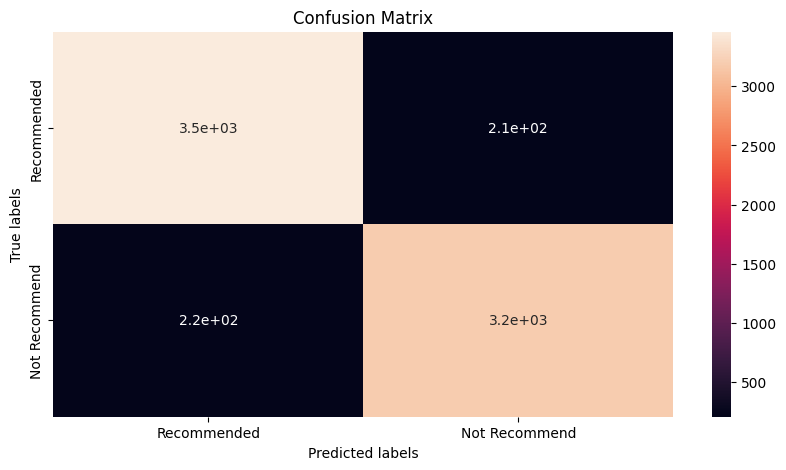

In [152]:
cfu2 = confusion_matrix(y_test, pred_svm1_)
ax= plt.subplot()
labels = ['Recommended', 'Not Recommend']
sns.heatmap(cfu2, annot=True, ax = ax) #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)

* From the confusion matrix we can say our model is predicting  `200 False Positive` and `230 False Negative`.

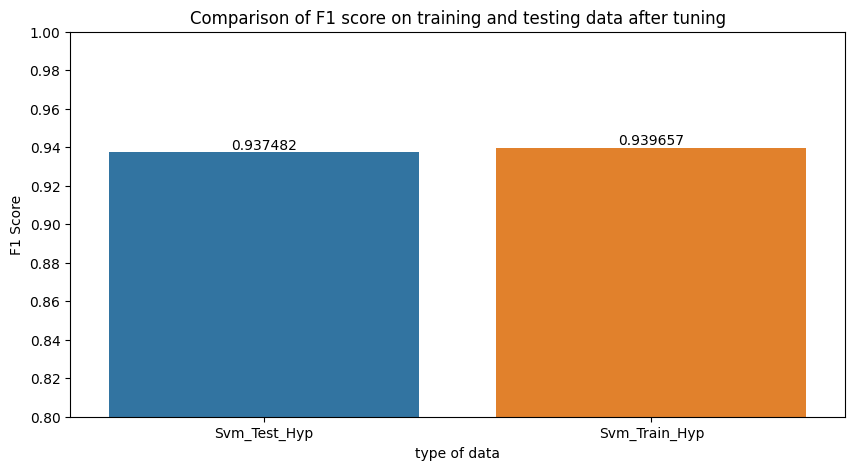

In [153]:
f1_svm_test_hyp = f1_score(y_test,pred_svm1_)
f1_svm_train_hyp = f1_score(y_train,pred_svm2)
svm_df_hyp= pd.DataFrame([{'Svm_Test_Hyp':f1_svm_test_hyp,'Svm_Train_Hyp':f1_svm_train_hyp}])
svm_grf_hyp=sns.barplot(svm_df_hyp)
for bar in svm_grf_hyp.containers:
  svm_grf_hyp.bar_label(bar)
plt.title('Comparison of F1 score on training and testing data after tuning')
plt.xlabel('type of data')
plt.ylabel('F1 Score')
plt.ylim(0.8,1)
plt.yticks([i/100 for i in range(80,102,2)])
plt.show()

#### Which hyperparameter optimization technique have you used and why?

We have used RandomSearchCV for hyperparameter tuning of this model because it give accurate hyperparameters and Random search is more computationally efficient.
plotting the matrix after Hyperparameter tuning

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

As our model was performing good on both, test and train data before even applying hyperparameter tuning with a score of 93.64% on test data and 94.01 % on train data.

So after the tuning there is no such significant improvement in F1 Score of model.

##ML Model - 4 : Random Forest

* Fitting our model with training data and predicting on test data

In [154]:

rf = RandomForestClassifier()

# Fit the Algorithm
rf.fit(X_train,y_train)

# Predict on the model
y_pred_rf =rf.predict(X_test)

* Checking evaluation matrices on test data

In [155]:
print("Accuracy on test data:", accuracy_score(y_test, y_pred_rf))
print("Precision on test data:", precision_score(y_test, y_pred_rf))
print("Recall on test data:", recall_score(y_test, y_pred_rf))
print("F1_score on test data:", f1_score(y_test,y_pred_rf))

Accuracy on test data: 0.9310929116068907
Precision on test data: 0.9315634218289085
Recall on test data: 0.9250146455770357
F1_score on test data: 0.9282774838330394


* Now we fitting our model and predicting on Training data

In [156]:

rf1 = RandomForestClassifier()

# Fit the Algorithm
rf1.fit(X_train,y_train)

# Predict on the model
y_pred_rf1 =rf1.predict(X_train)

* Checking Evaluation matrices on training data

In [157]:
print("Accuracy on training data:", accuracy_score(y_train, y_pred_rf1))
print("Precision on training data:", precision_score(y_train, y_pred_rf1))
print("Recall on training data:", recall_score(y_train, y_pred_rf1))
print("F1_score on training data:", f1_score(y_train,y_pred_rf1))

Accuracy on training data: 0.9891672718470104
Precision on training data: 0.9868070531523532
Recall on training data: 0.9904507257448434
F1_score on training data: 0.9886255321852958


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Answer:

* We have used `RandomForest` for our classification Supervised ML model because it is a one of the best model for classification tasks and it tends to have high accuracy compared to other classification algorithms.
* It works well with both linear and nonlinear data, making it suitable for our problem statement because our dataset is also non-linear.

* Random Forest is less prone to overfitting compared to decision trees because it creates multiple trees and then averages their results. This ensemble approach helps to reduce variance and improve generalization.

Plotting the F1 Score on both Training and Testing data

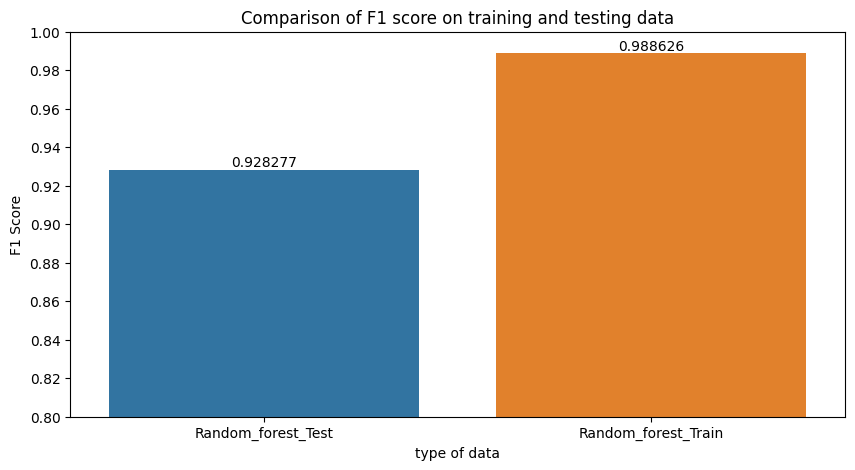

In [158]:
f1_rf_test = f1_score(y_test,y_pred_rf)
f1_rf_train = f1_score(y_train,y_pred_rf1)
rf_df= pd.DataFrame([{'Random_forest_Test':f1_rf_test,'Random_forest_Train':f1_rf_train}])
rf_grf=sns.barplot(rf_df)
for bar in rf_grf.containers:
  rf_grf.bar_label(bar)
plt.title('Comparison of F1 score on training and testing data')
plt.xlabel('type of data')
plt.ylabel('F1 Score')
plt.ylim(0.8,1)
plt.yticks([i/100 for i in range(80,102,2)])
plt.show()

* We can see that our` F1 score` is 92% on test data but 98% on training data which indicates the` overfitting` of our model so we will try to reduce it by Hyperparameter tuning in next steps.

#### 2. Cross- Validation & Hyperparameter Tuning

* Performing RandomSearchCV for getting best hyperparameters

In [159]:
param_grid_rf = {
    'n_estimators': [50,80,100,200,300],
    'max_depth': [1,2,6,7,8,9,10,20,30,40],
    'min_samples_split':[5,10,20,30,40,50,100,150,200],
    'min_samples_leaf': [1,2,8,10,20,40,50]
}

# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(rf, param_grid_rf,verbose=2,random_state = 42 ,cv=5,scoring='f1')

# Fit the RandomizedSearchCV object to the training data
random_search.fit(X_train, y_train)

# Get the best estimator
best_model_rf_rs = random_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=6, min_samples_leaf=40, min_samples_split=10, n_estimators=50; total time=   1.1s
[CV] END max_depth=6, min_samples_leaf=40, min_samples_split=10, n_estimators=50; total time=   1.1s
[CV] END max_depth=6, min_samples_leaf=40, min_samples_split=10, n_estimators=50; total time=   1.0s
[CV] END max_depth=6, min_samples_leaf=40, min_samples_split=10, n_estimators=50; total time=   0.8s
[CV] END max_depth=6, min_samples_leaf=40, min_samples_split=10, n_estimators=50; total time=   0.8s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=100, n_estimators=300; total time=   5.7s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=100, n_estimators=300; total time=   6.9s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=100, n_estimators=300; total time=   6.0s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=100, n_estimators=300; total time=   6.6s
[CV] END max_depth=8, min_

In [160]:
best_model_rf_rs.feature_importances_
print(best_model_rf_rs)

RandomForestClassifier(max_depth=9, min_samples_leaf=2, min_samples_split=30,
                       n_estimators=200)


* These are the best parameter we got after hyperparameter tuning

In [161]:
curr_param = best_model_rf_rs.get_params()
curr_param

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 9,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 30,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 200,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

* Now we will fit the model with best parameter we got after tuning to check for evaluation matrices

In [162]:
rf3 = RandomForestClassifier(**curr_param)

# Fit the Algorithm
rf3.fit(X_train,y_train)

# Predict on the model
y_pred_rf3 =rf3.predict(X_test)

* Checking evaluation matrices after tuning on testing data

In [163]:
print("Accuracy on test data:", accuracy_score(y_test, y_pred_rf3))
print("Precision on test data:", precision_score(y_test, y_pred_rf3))
print("Recall on test data:", recall_score(y_test, y_pred_rf3))
print("F1_score on test data:", f1_score(y_test,y_pred_rf3))

Accuracy on test data: 0.9390002824061
Precision on test data: 0.9406028368794326
Recall on test data: 0.9323374340949033
F1_score on test data: 0.9364518976169461


* Now we are Fitting our model on best parameter to predict on training data

In [164]:
rf4 = RandomForestClassifier(**curr_param)

# Fit the Algorithm
rf4.fit(X_train,y_train)

# Predict on the model
y_pred_rf4 =rf4.predict(X_train)

* Checking evaluation matrices after tuning on training data

In [165]:
print("Accuracy on training data:", accuracy_score(y_train, y_pred_rf4))
print("Precision on training data:", precision_score(y_train, y_pred_rf4))
print("Recall on training data:", recall_score(y_train, y_pred_rf4))
print("F1_score on training data:", f1_score(y_train,y_pred_rf4))

Accuracy on training data: 0.9512224642943597
Precision on training data: 0.9534225424601133
Recall on training data: 0.9434682964094728
F1_score on training data: 0.9484193011647255


* Plotting Confusion Matrix to check the performance of our model after hyperparameter tuning

[Text(0, 0.5, 'Recommended'), Text(0, 1.5, 'Not Recommend')]

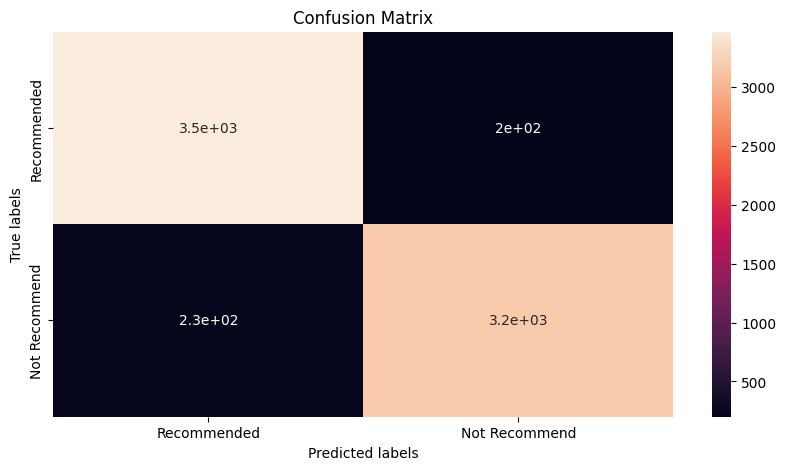

In [166]:
cfu3 = confusion_matrix(y_test, y_pred_rf3)
ax= plt.subplot()
labels = ['Recommended', 'Not Recommend']
sns.heatmap(cfu3, annot=True, ax = ax) #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)

* From the confusion matrix we can say our model is predicting `210 False Positive` and `240 False Negative`.

##### Which hyperparameter optimization technique have you used and why?

*  We have used `RandomSearchCV` for hyperparameter tuning of this model because it give accurate hyperparameters and Random search is more computationally efficient.


plotting the matrices after Hyperparameter tuning

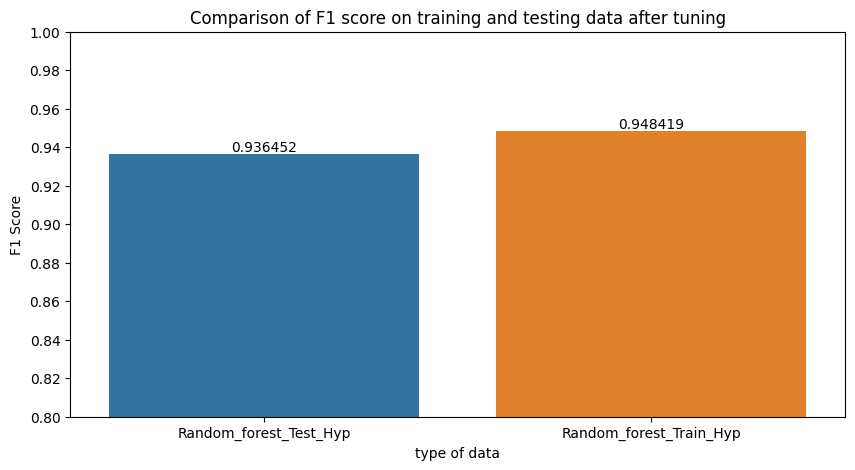

In [167]:
f1_rf_test_hyp = f1_score(y_test,y_pred_rf3)
f1_rf_train_hyp = f1_score(y_train,y_pred_rf4)
rf_df_hyp= pd.DataFrame([{'Random_forest_Test_Hyp':f1_rf_test_hyp,'Random_forest_Train_Hyp':f1_rf_train_hyp}])
rf_grf_hyp=sns.barplot(rf_df_hyp)
for bar in rf_grf_hyp.containers:
  rf_grf_hyp.bar_label(bar)
plt.title('Comparison of F1 score on training and testing data after tuning')
plt.xlabel('type of data')
plt.ylabel('F1 Score')
plt.ylim(0.8,1)
plt.yticks([i/100 for i in range(80,102,2)])
plt.show()

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes,we can clearly see improvement on F1 score after tuning to our best parameters as `previously it was 92% on testing and 98% on training data`
but after tuning it` increase to 93% on test data and 94% on training data` which indicates it reduced Overfitting significantly and also enhanced it performance and generalising very well on unseen data.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We are choosing here `F1 score` because in this type of problem type 1 error and type 2 error doesn't show a bigger consequence if our prediction goes wrong so when we cannot define the consequence of our wrong prediction we choose f1 score because it consist of both precision and recall(it's harmonic sum of these two metrices).

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

In [168]:
model_ovrl_df = pd.DataFrame([{'Decision Tree':f1_dt_test_hyp,'KNN':f1_knn_test_hyp,'SVM':f1_svm_test_hyp,'Random Forest':f1_rf_test_hyp}])

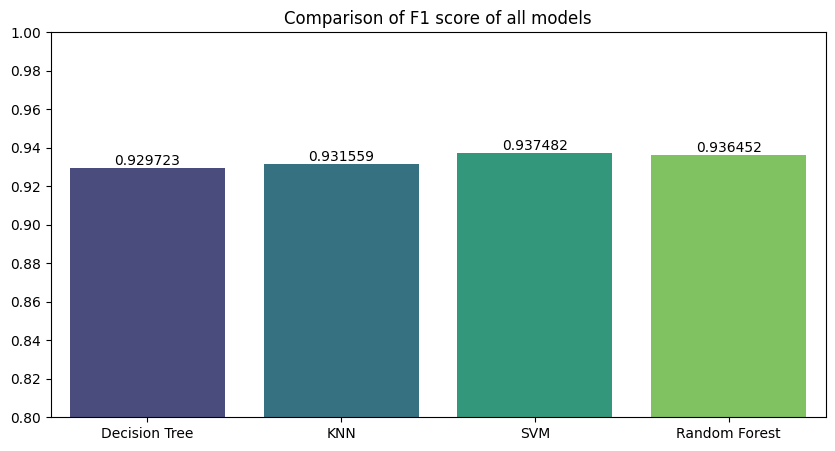

In [169]:
model_ovrl_grf = sns.barplot(model_ovrl_df,palette='viridis')
for bar in model_ovrl_grf.containers:
  model_ovrl_grf.bar_label(bar)
plt.title('Comparison of F1 score of all models')
plt.ylim(0.8,1)
plt.yticks([i/100 for i in range(80,102,2)])
plt.show()

After seeing all these model's performance across all defined models we choose` SVM model` for our problem because in this our difference between `training(94.01%)` and `test data(93.65%)` metrices is minimal as compared to others and after Cross validation and hyperparamter tuning our overfitting issue also get minimized.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

We have used here `RandomforestClassifier` for evaluating feature importance of all the features of our dataset.

In [170]:
rf_fea = RandomForestClassifier()
rf_fea.fit(df.iloc[:,:-1],df.iloc[:,-1:])
rf_fea_imp = rf_fea.feature_importances_
indices = np.argsort(rf_fea_imp)
features =df.iloc[:,:-1].columns

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


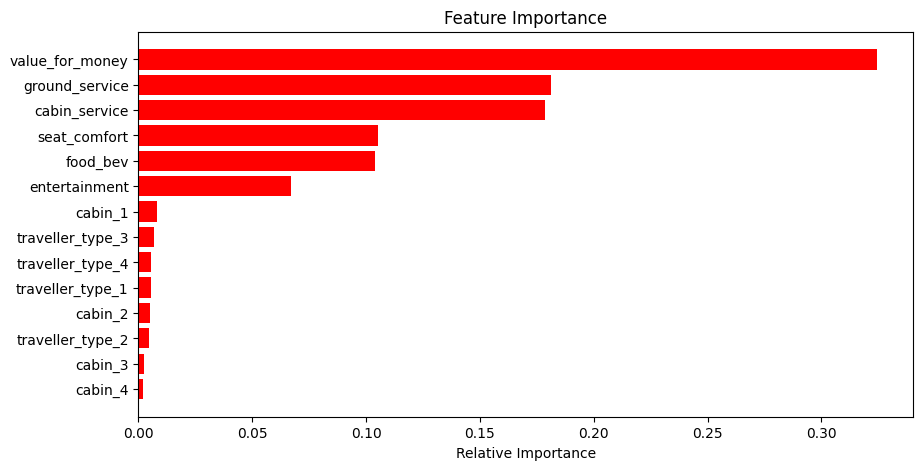

In [171]:
#Visualizing the feature importance
plt.title('Feature Importance')
plt.barh(range(len(indices)), rf_fea_imp[indices], color='red', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')

plt.show()

we have used` RandomForestClassifier` feature importance tool to get  insights into the model's decision-making process and the significance of each feature can be gained. Visualizations, such as summary plots or bar plots, offer interpretability.

Feature importance in Random Forest is calculated based on how much each feature contributes to decreasing the impurity (e.g., Gini impurity or entropy) in the nodes of the trees. Features that are used at the top of the trees (closer to the root) are considered more important, as they are used to make more significant splits that result in a more pure classification or regression.

## ***8.*** ***Future Work (Optional)***

### 1. Pickle.


### a. Save the best performing ml model in a pickle file format for deployment process.


In [172]:
# Save the File
# loading library
import pickle

with open('svm_model_pkl', 'wb') as files:
    pickle.dump(svm_model, files)

In [173]:
#Check for taking any 2 values from input
X_test.iloc[50:52,:]

,PC1,PC2,PC3,PC4,PC5,PC6
9966,-4.068972,-1.101773,-1.259965,-0.737934,-0.129218,0.376585
13054,4.593021,-0.462198,-0.232336,-0.159003,-0.329266,-1.079515


In [174]:
#Check for taking any 2 values from output
y_test.iloc[50:52]

,recommended
9966,0
13054,1


### b. Again Load the saved model file and try to predict unseen data for a sanity check.


In [175]:
# load saved model
with open('svm_model_pkl' , 'rb') as f:
    sv = pickle.load(f)

# check prediction

#Passing all thest values one by one and check for output
print(sv.predict([[-4.085949,1.071213,-1.333797,0.196208,0.640413,-0.152663]]))
print(sv.predict([[4.645729,0.533198,0.356625,1.102814,0.578457,-0.042073]]))

[0]
[1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [176]:
# Load the File and predict unseen data.
print(sv.predict([[-4.64748,1.3242536,-0.3397,0.19465438208,1.74866313,-1.152663]]))

[0]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


### 2. Joblib


### a. Save the best performing ml model in a joblib file format for deployment process.


In [177]:
# loading dependency
import joblib

joblib.dump(svm_model , 'svm_jlib')

['svm_jlib']

In [178]:
svm_model_jlib = joblib.load('svm_jlib')

### b. Again Load the saved model file and try to predict unseen data for a sanity check.


In [179]:
#Passing all thest values one by one and check for output
print(svm_model_jlib.predict([[-4.085949,1.071213,-1.333797,0.196208,0.640413,-0.152663]]))
print(svm_model_jlib.predict([[4.645729,0.533198,0.356625,1.102814,0.578457,-0.042073]]))

[0]
[1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [180]:
# Load the File and predict unseen data.
print(svm_model_jlib.predict([[-4.64748,1.3242536,-0.3397,0.19465438208,1.74866313,-1.152663]]))

[0]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


---


# **Conclusion**

Our dataset consists of airline reviews spanning from 2006 to 2019, covering various popular airlines worldwide. It comprises 131,895 rows and 17 columns. To enhance data quality, you performed several data preprocessing steps, including converting date columns to datetime format, adjusting rating columns, and addressing issues with the "date_flown" column and tackling our NaN values.

During Exploratory Data Analysis (EDA), you discovered that the majority of customers (72%) opt for the economic class, followed by 19.4% in business class. Ratings predominantly fall within the 1-5 range, except for the "overall_rating," which ranges from 1-10. Insights from the EDA process informed your subsequent hypothesis testing, where t-tests, chi-square, and ANOVA tests were employed to validate assumptions.

Feature engineering involved encoding categorical variables and implementing Principal Component Analysis (PCA) for dimensionality reduction. The decision to retain only the first six principal components, explaining 92% of the data variance, allows for a more streamlined dataset with reduced complexity. Finally, the data was split into a training set (70%) and a testing set (30%) for model development and evaluation.

For the classification problem, four models were employed: `Decision Tree`, `KNN`, `SVM`, and `Random Forest`. Initially, the Decision Tree model exhibited overfitting, but through cross-validation and hyperparameter tuning, this issue was mitigated. Subsequent models, including KNN, SVM, and Random Forest, were then applied.

In terms of classification metrics, the business context prioritized F1_score, followed by Precision and Recall, with accuracy considered third. All four models achieved accuracy rates exceeding 90%, and after evaluation, SVM emerged as the top-performing model by a slight margin.

The evaluation metrics comparison highlighted SVM's superior accuracy, making it the preferred choice among the models tested. Notably, the most influential features contributing to predictions were identified as "Value for money" and "ground_service."

The developed classifier models are valuable for predicting passenger referrals, allowing airlines to identify impactful passengers who can potentially bring in more revenue. The insights gained from the models suggest that improving cabin service, ground service, food and beverage offerings, entertainment, and seat comfort will enhance the likelihood of passengers recommending the airline to others. This strategic focus on key features can contribute to business growth and increased customer satisfaction.

---
*End of notebook.*
